# Focused model comparison

This notebook compares only the current clean-Edge families: Adapted ArGEnT-inspired attention operator, GC-PointNet, LC-PointNet, and GC-PointNet_weighted when present. It discovers checkpoints and uses their saved architecture, feature columns, and normalization statistics. It does not train, rewrite HDF5 files, or claim certification-grade fatigue life.

The geometry-level holdout is labelled **validation-split evaluation** unless independence from training, validation, early stopping, checkpoint selection, and hyperparameter selection is proved by checkpoint metadata.

In [40]:
from __future__ import annotations
import ast, hashlib, importlib.util, json, os, sys, time, warnings
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown
try:
    import torch
    import h5py
except ImportError as exc:
    raise RuntimeError('Install torch and h5py in the selected notebook kernel before executing this comparison.') from exc
CURRENT_DIR = Path.cwd()
REPO_ROOT = CURRENT_DIR if (CURRENT_DIR / 'Uniform').exists() else CURRENT_DIR.parent
if not (REPO_ROOT / 'Uniform').exists(): raise RuntimeError(f'Repository root not found from {CURRENT_DIR}')
COMPARISON_DIR = REPO_ROOT / 'Comparison'
RESULTS_DIR = COMPARISON_DIR / 'results'; FIGURES_DIR = RESULTS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True); FIGURES_DIR.mkdir(parents=True, exist_ok=True)
sys.path.insert(0, str(COMPARISON_DIR))
import eval_helpers as eh
SPLIT_SEED, EVAL_FRACTION = 42, 0.20
FAMILIES = ['ArGEnT_self_att_noSDF', 'PointNetMLPJoint', 'PointNetMLPJoint_FP', 'PointNetMLPJoint_weighted']
DATASETS = {'Uniform': REPO_ROOT / 'Data_gen' / 'output' / 'disc_dataset_edge_deriv_uniform.h5', 'Zonal': REPO_ROOT / 'Data_gen' / 'output' / 'disc_dataset_edge_deriv_zonal.h5'}
COMMIT = __import__('subprocess').check_output(['git','rev-parse','HEAD'], cwd=REPO_ROOT, text=True).strip()
display(Markdown(f'**Inspected commit:** `{COMMIT}`\n\n**Results directory:** `{RESULTS_DIR}`'))

**Inspected commit:** `ae6197d15a5a23c99f72ca45fd14f3cfb8e66df5`

**Results directory:** `c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Comparison\results`

## Checkpoint discovery and integrity

In [30]:
def sha256(path):
    digest = hashlib.sha256()
    with open(path, 'rb') as stream:
        for block in iter(lambda: stream.read(1024 * 1024), b''): digest.update(block)
    return digest.hexdigest()
def decode(value):
    return value.decode() if isinstance(value, bytes) else value
def discover():
    rows=[]
    for regime in ('Uniform','Zonal'):
        for family in FAMILIES:
            folder = REPO_ROOT / regime / 'Edge' / family
            scripts = list(folder.glob('Training_script*.py'))
            checkpoints = sorted((folder / 'Trained_models').glob('*.pt'))
            if not folder.exists() or not checkpoints:
                rows.append({'regime':regime,'ablation':'Edge','model_family':family,'status':'missing checkpoint','checkpoint_path':str(checkpoints[0]) if checkpoints else None}); continue
            for path in checkpoints:
                status='discovered'; metadata={}
                try:
                    payload=torch.load(path, map_location='cpu', weights_only=False)
                    metadata={k: payload.get(k) for k in ['arch','model_name','best_val_loss','loss_type','target_names','extra_feat_cols','h5_filename','representation','train_sample_ids','val_sample_ids'] if k in payload}
                    required=['arch','target_mean','target_std','coord_center','coord_half_range']
                    missing=[k for k in required if k not in payload]
                    if missing: status='incompatible: missing normalization/architecture '+','.join(missing)
                except Exception as exc: status='incompatible: '+type(exc).__name__+': '+str(exc)
                rows.append({'regime':regime,'ablation':'Edge','model_family':family,'status':status,'checkpoint_path':str(path),'file_size_bytes':path.stat().st_size,'sha256':sha256(path),'training_scripts':[str(x) for x in scripts],**metadata})
    report=pd.DataFrame(rows)
    dup=report.dropna(subset=['sha256']).groupby('sha256').filter(lambda x: len(x)>1)
    if not dup.empty: report.loc[report.sha256.isin(dup.sha256),'status']='incompatible: duplicate byte-identical checkpoint'
    report.to_json(RESULTS_DIR/'checkpoint_integrity.json', orient='records', indent=2)
    return report
checkpoint_report=discover(); display(checkpoint_report[['regime','model_family','status','checkpoint_path','file_size_bytes','sha256']])

,regime,model_family,status,checkpoint_path,file_size_bytes,sha256
0,Uniform,ArGEnT_self_att_noSDF,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Un...,3552022,82bb0839e072408a7229175ba36447c790266d36809d3a...
1,Uniform,PointNetMLPJoint,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Un...,2963050,f32dadf7cbe7b2f9bec429b26d918785518baecf391507...
2,Uniform,PointNetMLPJoint_FP,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Un...,3099490,9847567d29a7219a71568a23e9ca183a538de46d22f08f...
3,Uniform,PointNetMLPJoint_weighted,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Un...,2962922,2d3daebd534919d00001775de84178a386bcb4ee1091f2...
4,Zonal,ArGEnT_self_att_noSDF,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zo...,3459222,04d489d391f831a2f6e5605410590e7f08ae8345d1f633...
5,Zonal,PointNetMLPJoint,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zo...,2965098,e155d55a22d9ef9055c3d3b62b1a1d199bb02f17946b5b...
6,Zonal,PointNetMLPJoint_FP,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zo...,3098274,5a4051f09936adfe3f233fa3cea2405015372d7f2ddab3...
7,Zonal,PointNetMLPJoint_weighted,discovered,c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zo...,2967530,2fc9476d3acb08b12b3df6876fc71149bce1e5f1d5e46a...


## HDF5 schema, split, and provenance

In [31]:
def load_samples(path):
    samples=[]
    with h5py.File(path,'r') as h5:
        representation=decode(h5.attrs.get('representation',''))
        if representation != 'edge': raise ValueError(f'{path.name}: expected representation edge, got {representation!r}')
        for key in sorted(h5['samples'].keys()):
            g=h5['samples'][key]
            def arr(name, default=None): return np.asarray(g[name]) if name in g else default
            coords=arr('node_coords_mm'); stress=arr('stress_max_vm'); life=arr('life_raw')
            if coords is None or stress is None or life is None: raise ValueError(f'{path.name}/{key}: missing required target fields')
            sample_id=decode(g.attrs.get('sample_id', key))
            attrs={str(k):decode(v) for k,v in g.attrs.items()}
            samples.append({'sample_key':key,'sample_id':str(sample_id),'attrs':attrs,'coords':coords.astype('float32'),'stress':stress.astype('float32').reshape(-1),'loglife':np.log10(np.clip(life.astype('float64').reshape(-1),1e-30,None)).astype('float32'),'zone_id':arr('zone_id',np.full(len(coords),-1)).reshape(-1),'subzone_id':arr('subzone_id',np.full(len(coords),np.nan)).reshape(-1),'arc_length_mm':arr('arc_length_mm',np.arange(len(coords),dtype='float32')).reshape(-1),'node_features':arr('node_features',np.empty((len(coords),0),dtype='float32'))})
    return samples
def split_samples(samples):
    rng=np.random.default_rng(SPLIT_SEED); order=rng.permutation(len(samples)); n_eval=max(1,int(round(len(samples)*EVAL_FRACTION)))
    eval_pos=np.sort(order[:n_eval]).tolist(); train_pos=np.sort(order[n_eval:]).tolist()
    return train_pos,eval_pos
all_samples={}; split_records={}
for regime,path in DATASETS.items():
    samples=load_samples(path); train_pos,eval_pos=split_samples(samples); all_samples[regime]=samples
    split_records[regime]={'hdf5_filename':path.name,'total_geometry_count':len(samples),'evaluation_geometry_count':len(eval_pos),'split_seed':SPLIT_SEED,'split_fraction':EVAL_FRACTION,'training_sample_ids':[samples[i]['sample_id'] for i in train_pos],'evaluation_sample_ids':[samples[i]['sample_id'] for i in eval_pos],'training_positional_indices':train_pos,'evaluation_positional_indices':eval_pos,'timestamp_utc':time.strftime('%Y-%m-%dT%H:%M:%SZ',time.gmtime()),'notebook_commit_sha':COMMIT,'evaluation_label':'validation-split evaluation','independence_basis':'A new geometry holdout is not proved independent of model validation/checkpoint selection.'}
with open(RESULTS_DIR/'evaluation_split_provenance.json','w') as stream: json.dump(split_records,stream,indent=2)
display(pd.DataFrame([{'regime':k,'geometries':v['total_geometry_count'],'evaluation_geometries':v['evaluation_geometry_count'],'label':v['evaluation_label']} for k,v in split_records.items()]))

,regime,geometries,evaluation_geometries,label
0,Uniform,5000,1000,validation-split evaluation
1,Zonal,5000,1000,validation-split evaluation


## Model reconstruction and inference

In [32]:
def import_local(path, name):
    spec=importlib.util.spec_from_file_location(name,path); module=importlib.util.module_from_spec(spec); spec.loader.exec_module(module); return module

def reconstruct(row):
    folder=Path(row['checkpoint_path']).parent.parent; family=row['model_family']; ckpt=torch.load(row['checkpoint_path'],map_location='cpu',weights_only=False); arch=dict(ckpt['arch'])
    pn=import_local(folder/'pn_models.py', f'pn_{folder.parent.name}_{folder.name}_{row.regime}')
    sys.modules['pn_models']=pn
    if family=='PointNetMLPJoint_FP':
        if not hasattr(pn,'build_fp_model_from_arch'): raise RuntimeError('FP checkpoint requires build_fp_model_from_arch; refusing regular PointNet fallback')
        model=pn.build_fp_model_from_arch(arch)
    elif family in ('PointNetMLPJoint','PointNetMLPJoint_weighted'):
        model=pn.build_model_from_arch(arch)
    else:
        bench=import_local(folder/'benchmarks.py',f'bench_{row.regime}')
        if not hasattr(bench,'ArGEnTDeepONet'): raise RuntimeError('No ArGEnTDeepONet found in own benchmarks.py')
        defaults={'hidden_dim':128,'num_heads':4,'num_layers':2,'output_dim':128,'out_channels':1,'attention_type':'self','use_sdf':False,'in_ch_geom':2}
        defaults.update({k:v for k,v in arch.items() if k in defaults})
        if 'out_channels' not in arch and 'bias' in ckpt['model_state']: defaults['out_channels']=int(ckpt['model_state']['bias'].shape[0])
        model=bench.ArGEnTDeepONet(**defaults)
    model.load_state_dict(ckpt['model_state'],strict=True)
    model.eval()
    return model,ckpt

def feature_matrix(sample, ckpt):
    cols=ckpt.get('extra_feat_cols',[]) or []; available=sample['node_features']
    if cols and available.shape[1] < len(cols): raise ValueError(f'missing required extra-feature columns: {cols}')
    extra=available[:,:len(cols)] if cols else np.empty((len(sample['coords']),0),dtype='float32')
    center=np.asarray(ckpt['coord_center'],dtype='float32'); half=np.asarray(ckpt['coord_half_range'],dtype='float32'); coords=(sample['coords']-center)/np.maximum(half,1e-8)
    if extra.shape[1]:
        stats=ckpt.get('extra_feat_stats')
        if stats is None: raise ValueError('missing extra-feature normalization statistics')
        if isinstance(stats,dict): mean=np.asarray(stats['mean'],dtype='float32'); std=np.asarray(stats['std'],dtype='float32')
        else: mean=np.asarray(stats[0],dtype='float32'); std=np.asarray(stats[1],dtype='float32')
        extra=(extra-mean)/np.maximum(std,1e-8)
    return coords,extra

def predict(model, sample, ckpt):
    coords,extra=feature_matrix(sample,ckpt); x=torch.from_numpy(coords[None]); q=x.clone()
    with torch.no_grad():
        try: out=model(x,q)
        except TypeError: out=model(torch.cat([x,torch.from_numpy(extra[None])],dim=-1),q)
    out=out.detach().cpu().numpy()
    if out.ndim!=3 or out.shape[0]!=1 or out.shape[2]!=2: raise ValueError(f'prediction shape must be [B,Q,2], got {out.shape}')
    mean=np.asarray(ckpt['target_mean']); std=np.asarray(ckpt['target_std']); out=out*std+mean
    return out[0,:,0],out[0,:,1]

node_frames=[]; geometry_frames=[]; load_errors=[]
for _,row in checkpoint_report.iterrows():
    if row.status!='discovered': continue
    try:
        model,ckpt=reconstruct(row); expected=ckpt.get('target_names',['Stress','LogLife'])
        if len(expected)!=2: raise ValueError(f'incompatible target dimensions: {expected}')
        for i in split_records[row.regime]['evaluation_positional_indices']:
            s=all_samples[row.regime][i]; ps,pl=predict(model,s,ckpt); base=pd.DataFrame({'regime':row.regime,'ablation':'Edge','model_family':row.model_family,'sample_key':s['sample_key'],'sample_id':s['sample_id'],'node_idx':np.arange(len(s['coords'])),'x_mm':s['coords'][:,0],'r_mm':s['coords'][:,1],'zone_id':s['zone_id'],'subzone_id':s['subzone_id'],'arc_length_mm':s['arc_length_mm'],'true_stress':s['stress'],'pred_stress':ps,'true_loglife':s['loglife'],'pred_loglife':pl}); base['zone_name']=base.zone_id.map(eh.ZONE_ID_TO_NAME); base['subzone_name']=base.subzone_id.map(eh.SUBZONE_ID_TO_NAME); node_frames.append(base)
    except Exception as exc: load_errors.append({'regime':row.regime,'model_family':row.model_family,'checkpoint_path':row.checkpoint_path,'status':'load/inference failed: '+repr(exc)})
nodes=pd.concat(node_frames,ignore_index=True) if node_frames else pd.DataFrame(); pd.DataFrame(load_errors).to_json(RESULTS_DIR/'inference_errors.json',orient='records',indent=2); display(pd.DataFrame(load_errors) if load_errors else nodes.groupby(['regime','model_family']).sample_id.nunique().reset_index(name='evaluation_geometries'))

,regime,model_family,evaluation_geometries
0,Uniform,ArGEnT_self_att_noSDF,1000
1,Uniform,PointNetMLPJoint,1000
2,Uniform,PointNetMLPJoint_FP,1000
3,Uniform,PointNetMLPJoint_weighted,1000
4,Zonal,ArGEnT_self_att_noSDF,1000
5,Zonal,PointNetMLPJoint,1000
6,Zonal,PointNetMLPJoint_FP,1000
7,Zonal,PointNetMLPJoint_weighted,1000


## Metrics and figures

,regime,ablation,model_family,target,MSE,RMSE,MAE,R2 (log),MAPE (%),MPE (%),Max_PE (%),RMSE_raw,MSE_raw_life,R2_raw_life
0,Uniform,Edge,ArGEnT_self_att_noSDF,LogLife,0.001134,0.033674,0.013740,0.999429,3.222819,0.250998,1424.409526,1.310832e+07,1.718279e+14,0.999404
1,Uniform,Edge,ArGEnT_self_att_noSDF,Stress,36.798455,6.066173,2.048409,0.998906,NaN,NaN,NaN,NaN,NaN,NaN
2,Uniform,Edge,PointNetMLPJoint,LogLife,0.000888,0.029803,0.014685,0.999553,3.435209,0.592429,1417.716757,2.122338e+07,4.504318e+14,0.998437
3,Uniform,Edge,PointNetMLPJoint,Stress,21.068978,4.590096,2.025149,0.999374,NaN,NaN,NaN,NaN,NaN,NaN
4,Uniform,Edge,PointNetMLPJoint_FP,LogLife,0.000481,0.021929,0.010598,0.999758,2.466847,0.231972,3121.280230,2.050321e+07,4.203816e+14,0.998541
5,Uniform,Edge,PointNetMLPJoint_FP,Stress,10.853853,3.294519,1.438051,0.999677,NaN,NaN,NaN,NaN,NaN,NaN
6,Uniform,Edge,PointNetMLPJoint_weighted,LogLife,0.000861,0.029347,0.014400,0.999566,3.346173,0.315118,2331.016821,2.383670e+07,5.681883e+14,0.998028
7,Uniform,Edge,PointNetMLPJoint_weighted,Stress,20.241433,4.499048,1.977076,0.999398,NaN,NaN,NaN,NaN,NaN,NaN
8,Zonal,Edge,ArGEnT_self_att_noSDF,LogLife,0.002014,0.044880,0.016049,0.999002,3.839212,0.507221,1262.767681,2.123248e+07,4.508183e+14,0.997440
9,Zonal,Edge,ArGEnT_self_att_noSDF,Stress,36.914829,6.075757,2.025810,0.998903,NaN,NaN,NaN,NaN,NaN,NaN


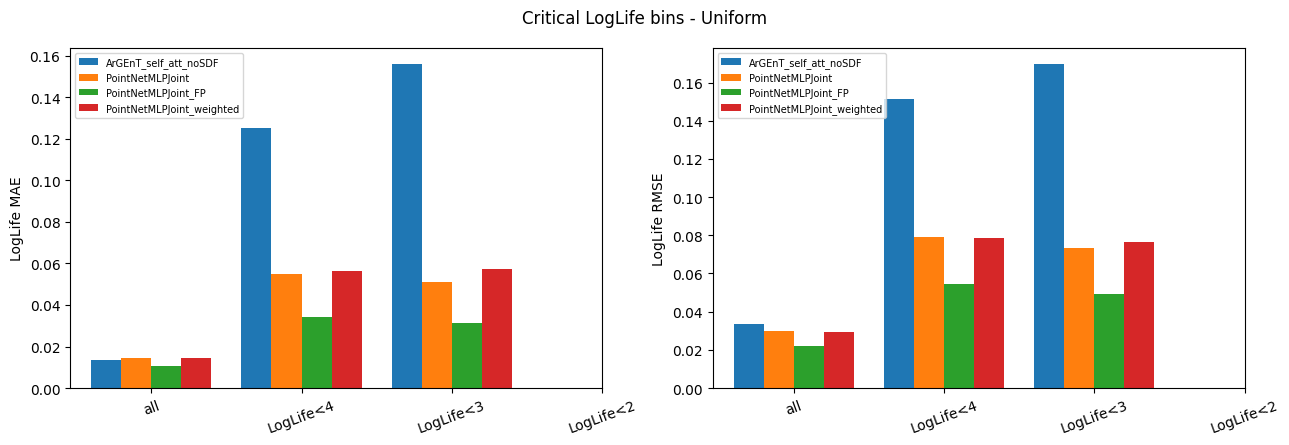

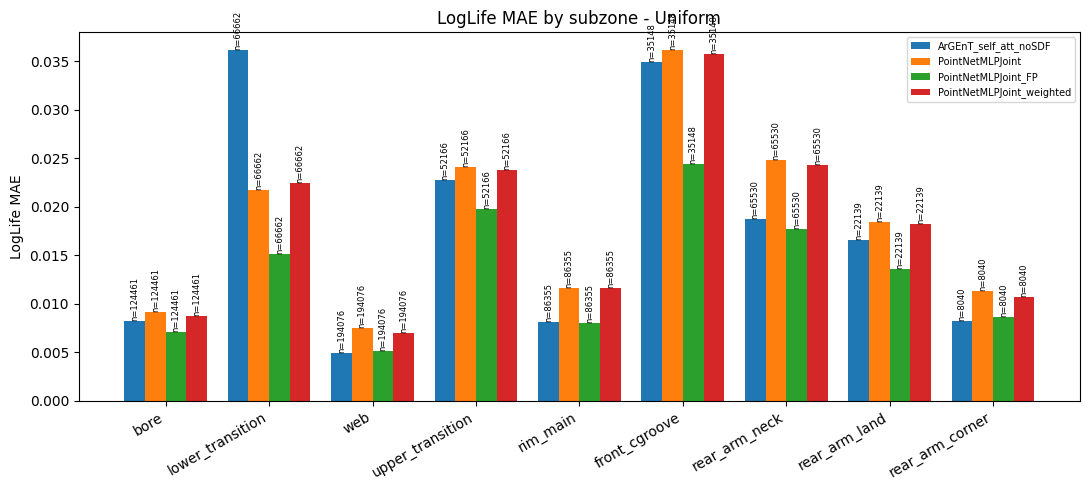

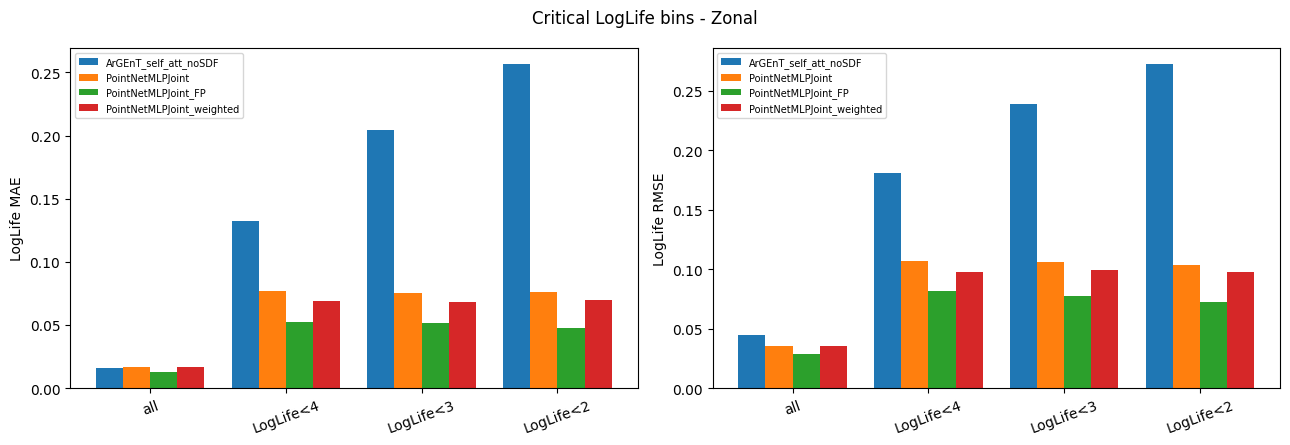

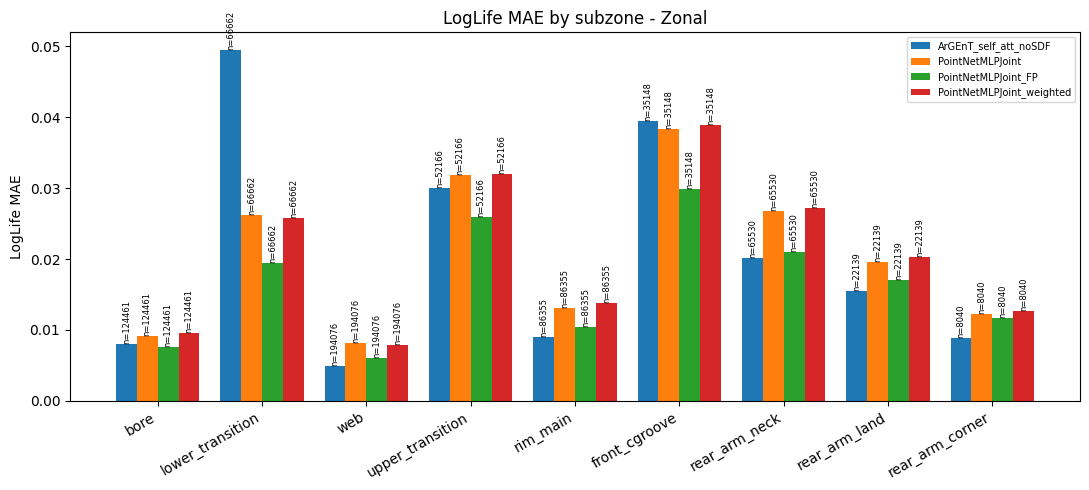

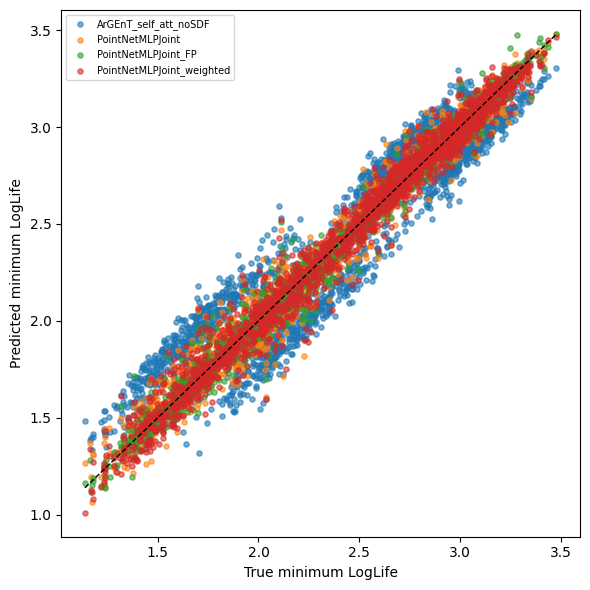

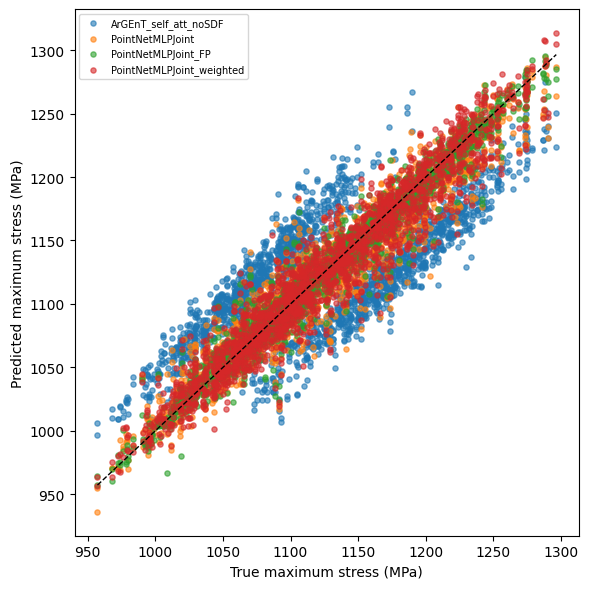

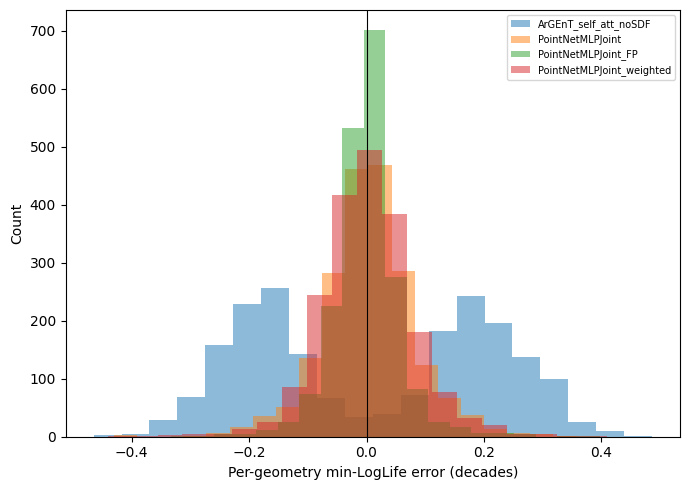

In [33]:
pooled=eh.pooled_metrics_from_nodes(nodes); bins=eh.loglife_bin_metrics(nodes); zones=eh.zone_metrics_from_nodes(nodes); geom=eh.geometry_level_metrics(nodes); geom_summary=eh.geometry_metrics_summary(geom)
for name,frame in [('pooled_metrics',pooled),('critical_bins',bins),('subzone_metrics',zones),('geometry_metrics',geom),('geometry_summary',geom_summary)]: eh.save_table(frame,RESULTS_DIR,name)
representatives={}
if not nodes.empty:
    for regime in bins.regime.unique():
        eh.plot_bin_bar(bins[bins.regime==regime],'Critical LogLife bins - '+regime,FIGURES_DIR,'critical_bins_'+regime.lower())
        eh.plot_zone_bar(zones[zones.regime==regime],'LogLife MAE by subzone - '+regime,FIGURES_DIR,'subzone_mae_'+regime.lower())
    eh.plot_geometry_scatter(geom,FIGURES_DIR,'geometry')
    paired=eh.paired_argent_fp_diff(geom); paired.to_csv(RESULTS_DIR/'fp_minus_argent_critical_life.csv',index=False)
    weighted=geom[geom.model_family=='PointNetMLPJoint_weighted']; regular=geom[geom.model_family=='PointNetMLPJoint']
    if not weighted.empty and not regular.empty: weighted.merge(regular,on=['regime','ablation','sample_id'],suffixes=('_weighted','_regular')).to_csv(RESULTS_DIR/'weighted_minus_unweighted_critical_life.csv',index=False)
    for regime in geom.regime.unique():
        representatives[regime]=eh.select_representative_geometries(geom,regime,'Edge',disagreement_family='PointNetMLPJoint_FP')
        for label,sample_id in representatives[regime].items():
            if sample_id is None: continue
            by_model={fam:nodes[(nodes.regime==regime)&(nodes.sample_id==sample_id)&(nodes.model_family==fam)] for fam in nodes[nodes.regime==regime].model_family.unique()}
            by_model={fam:frame for fam,frame in by_model.items() if not frame.empty}
            if by_model:
                eh.plot_field_comparison(by_model,'true_stress','pred_stress','MPa',f'{regime} Edge {label} Stress',mark_extrema='max',out_dir=FIGURES_DIR,filename=f'{regime}_{label}_stress')
                eh.plot_field_comparison(by_model,'true_loglife','pred_loglife','decades',f'{regime} Edge {label} LogLife',mark_extrema='min',out_dir=FIGURES_DIR,filename=f'{regime}_{label}_loglife')
                eh.plot_arc_length_error(by_model,f'{regime} Edge {label}',FIGURES_DIR,f'{regime}_{label}_arc_length')
with open(RESULTS_DIR/'representative_geometry_ids.json','w') as stream: json.dump(representatives,stream,indent=2,default=str)
display(pooled)

## Cautious interpretation and summary

In [34]:
def relation(table, family_a, family_b, target='LogLife', metric='MAE'):
    a=table[(table.model_family==family_a)&(table.target==target)][metric].mean(); b=table[(table.model_family==family_b)&(table.target==target)][metric].mean(); return 'improves' if a < b else 'does not improve' if np.isfinite(a) and np.isfinite(b) else 'not determined'
available=checkpoint_report[checkpoint_report.status=='discovered'].groupby(['regime','model_family']).size().reset_index()[['regime','model_family']].to_dict('records')
lines=[f'# Model comparison summary\n\nRepository commit: `{COMMIT}`\n\nEvaluation label: **validation-split evaluation**. The split is a deterministic 20% geometry holdout (seed 42); independence from checkpoint selection cannot be proved.']
lines.append('\n## Availability and compatibility\n\n'+checkpoint_report[['regime','model_family','status','checkpoint_path']].to_markdown(index=False))
lines.append('\n## Principal metrics\n\n'+(pooled.to_markdown(index=False) if not pooled.empty else 'No compatible models produced predictions.'))
if not pooled.empty:
    for regime in pooled.regime.unique():
        sub=pooled[pooled.regime==regime]; lines.append(f'\n## Interpretation: {regime}\n\nFP versus regular PointNet pooled LogLife MAE: {relation(sub,"PointNetMLPJoint_FP","PointNetMLPJoint")}. Pooled R2 alone is not used to declare a winner.')
lines.append('\n## Limitations\n\nResults are limited to discovered checkpoints and compatible clean-Edge schemas. Missing or failed models remain listed above. Raw-life percentage metrics are secondary diagnostics and may be inflated by small true-life values. Critical-node and subzone comparisons are evaluation-split diagnostics, not certification evidence.')
summary='\n'.join(lines); (RESULTS_DIR/'comparison_summary.md').write_text(summary,encoding='utf-8'); display(Markdown(summary))

# Model comparison summary

Repository commit: `ae6197d15a5a23c99f72ca45fd14f3cfb8e66df5`

Evaluation label: **validation-split evaluation**. The split is a deterministic 20% geometry holdout (seed 42); independence from checkpoint selection cannot be proved.

## Availability and compatibility

| regime   | model_family              | status     | checkpoint_path                                                                                                                  |
|:---------|:--------------------------|:-----------|:---------------------------------------------------------------------------------------------------------------------------------|
| Uniform  | ArGEnT_self_att_noSDF     | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt    |
| Uniform  | PointNetMLPJoint          | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_78193d0f.pt          |
| Uniform  | PointNetMLPJoint_FP       | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\PointNetMLPJoint_FP\Trained_models\pnmlp_16932d84.pt                    |
| Uniform  | PointNetMLPJoint_weighted | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\PointNetMLPJoint_weighted\Trained_models\pn_s_full_ln_pos12_78193d0f.pt |
| Zonal    | ArGEnT_self_att_noSDF     | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt      |
| Zonal    | PointNetMLPJoint          | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_78193d0f.pt            |
| Zonal    | PointNetMLPJoint_FP       | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\PointNetMLPJoint_FP\Trained_models\pnmlp_16932d84.pt                      |
| Zonal    | PointNetMLPJoint_weighted | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\PointNetMLPJoint_weighted\Trained_models\pn_s_full_ln_pos12_78193d0f.pt   |

## Principal metrics

| regime   | ablation   | model_family              | target   |          MSE |      RMSE |       MAE |   R2 (log) |   MAPE (%) |    MPE (%) |   Max_PE (%) |      RMSE_raw |   MSE_raw_life |   R2_raw_life |
|:---------|:-----------|:--------------------------|:---------|-------------:|----------:|----------:|-----------:|-----------:|-----------:|-------------:|--------------:|---------------:|--------------:|
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | LogLife  |  0.00113394  | 0.0336741 | 0.0137403 |   0.999429 |    3.22282 |   0.250998 |      1424.41 |   1.31083e+07 |    1.71828e+14 |      0.999404 |
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | Stress   | 36.7985      | 6.06617   | 2.04841   |   0.998906 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Uniform  | Edge       | PointNetMLPJoint          | LogLife  |  0.000888242 | 0.0298034 | 0.014685  |   0.999553 |    3.43521 |   0.592429 |      1417.72 |   2.12234e+07 |    4.50432e+14 |      0.998437 |
| Uniform  | Edge       | PointNetMLPJoint          | Stress   | 21.069       | 4.5901    | 2.02515   |   0.999374 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Uniform  | Edge       | PointNetMLPJoint_FP       | LogLife  |  0.000480881 | 0.021929  | 0.0105979 |   0.999758 |    2.46685 |   0.231972 |      3121.28 |   2.05032e+07 |    4.20382e+14 |      0.998541 |
| Uniform  | Edge       | PointNetMLPJoint_FP       | Stress   | 10.8539      | 3.29452   | 1.43805   |   0.999677 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Uniform  | Edge       | PointNetMLPJoint_weighted | LogLife  |  0.000861275 | 0.0293475 | 0.0143998 |   0.999566 |    3.34617 |   0.315118 |      2331.02 |   2.38367e+07 |    5.68188e+14 |      0.998028 |
| Uniform  | Edge       | PointNetMLPJoint_weighted | Stress   | 20.2414      | 4.49905   | 1.97708   |   0.999398 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | LogLife  |  0.00201418  | 0.0448797 | 0.0160489 |   0.999002 |    3.83921 |   0.507221 |      1262.77 |   2.12325e+07 |    4.50818e+14 |      0.99744  |
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | Stress   | 36.9148      | 6.07576   | 2.02581   |   0.998903 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | PointNetMLPJoint          | LogLife  |  0.0012726   | 0.0356735 | 0.0164137 |   0.999369 |    3.8508  |   0.672409 |      2437.37 |   3.02602e+07 |    9.15681e+14 |      0.994801 |
| Zonal    | Edge       | PointNetMLPJoint          | Stress   | 19.2555      | 4.38811   | 1.97455   |   0.999428 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | PointNetMLPJoint_FP       | LogLife  |  0.000822852 | 0.0286854 | 0.012962  |   0.999592 |    3.0437  |   0.305034 |      2151.8  |   2.15815e+07 |    4.65761e+14 |      0.997356 |
| Zonal    | Edge       | PointNetMLPJoint_FP       | Stress   | 12.2557      | 3.50082   | 1.57427   |   0.999636 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | PointNetMLPJoint_weighted | LogLife  |  0.00124753  | 0.0353204 | 0.0166509 |   0.999382 |    3.88386 |   0.163403 |      1221.65 |   3.91131e+07 |    1.52983e+15 |      0.991314 |
| Zonal    | Edge       | PointNetMLPJoint_weighted | Stress   | 18.0945      | 4.25376   | 1.96901   |   0.999462 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |

## Interpretation: Uniform

FP versus regular PointNet pooled LogLife MAE: improves. Pooled R2 alone is not used to declare a winner.

## Interpretation: Zonal

FP versus regular PointNet pooled LogLife MAE: improves. Pooled R2 alone is not used to declare a winner.

## Limitations

Results are limited to discovered checkpoints and compatible clean-Edge schemas. Missing or failed models remain listed above. Raw-life percentage metrics are secondary diagnostics and may be inflated by small true-life values. Critical-node and subzone comparisons are evaluation-split diagnostics, not certification evidence.

## Critical-region evaluation report

All outputs in this section are labelled **validation-split evaluation**. This section adds the required Zonal + Edge paired comparisons, complete geometry-level critical fields, exactly three Zonal representative geometries, and cautious conclusions.

In [35]:
MIN_CRITICAL_NODES=30; PRINCIPAL=['ArGEnT_self_att_noSDF','PointNetMLPJoint','PointNetMLPJoint_FP','PointNetMLPJoint_weighted']
def _critical_rows(frame):
    rows=[]
    for (regime,ablation,family,sid),g in frame.groupby(['regime','ablation','model_family','sample_id']):
        g=g.sort_values('node_idx').reset_index(drop=True); life=g.true_loglife.to_numpy(); pred=g.pred_loglife.to_numpy(); stress=g.true_stress.to_numpy(); pstress=g.pred_stress.to_numpy(); ti,pi=int(np.argmin(life)),int(np.argmin(pred)); tsi,psi=int(np.argmax(stress)),int(np.argmax(pstress)); tx,tr=g.loc[ti,['x_mm','r_mm']]; px,pr=g.loc[pi,['x_mm','r_mm']]; tsx,tsr=g.loc[tsi,['x_mm','r_mm']]; psx,psr=g.loc[psi,['x_mm','r_mm']]; lower=g[g.subzone_name.eq('lower_transition')]; le=lower.pred_loglife.to_numpy()-lower.true_loglife.to_numpy()
        rows.append({'regime':regime,'ablation':ablation,'model_family':family,'sample_id':str(sid),'true_min_loglife':float(life[ti]),'pred_min_loglife':float(pred[pi]),'signed_min_loglife_error_decades':float(pred[pi]-life[ti]),'absolute_min_loglife_error_decades':float(abs(pred[pi]-life[ti])),'true_max_stress':float(stress[tsi]),'pred_max_stress':float(pstress[psi]),'signed_max_stress_error_mpa':float(pstress[psi]-stress[tsi]),'absolute_max_stress_error_mpa':float(abs(pstress[psi]-stress[tsi])),'true_min_x_mm':float(tx),'true_min_r_mm':float(tr),'pred_min_x_mm':float(px),'pred_min_r_mm':float(pr),'min_life_node_distance_mm':float(np.hypot(px-tx,pr-tr)),'true_max_stress_x_mm':float(tsx),'true_max_stress_r_mm':float(tsr),'pred_max_stress_x_mm':float(psx),'pred_max_stress_r_mm':float(psr),'max_stress_node_distance_mm':float(np.hypot(psx-tsx,psr-tsr)),'true_critical_zone':eh.ZONE_ID_TO_NAME.get(int(g.zone_id.iloc[ti])),'pred_critical_zone':eh.ZONE_ID_TO_NAME.get(int(g.zone_id.iloc[pi])),'true_critical_subzone':g.subzone_name.iloc[ti],'pred_critical_subzone':g.subzone_name.iloc[pi],'same_critical_zone':bool(g.zone_id.iloc[ti]==g.zone_id.iloc[pi]),'same_critical_subzone':bool(g.subzone_id.iloc[ti]==g.subzone_id.iloc[pi]) if g.subzone_id.notna().any() else None,'lower_transition_node_count':int(len(lower)),'lower_transition_mae':float(np.mean(np.abs(le))) if len(le) else np.nan,'lower_transition_rmse':float(np.sqrt(np.mean(le**2))) if len(le) else np.nan})
    return pd.DataFrame(rows)
def _paired(frame,left,right):
    a=frame[frame.model_family.eq(left)].set_index(['regime','sample_id']); b=frame[frame.model_family.eq(right)].set_index(['regime','sample_id']); common=a.index.intersection(b.index); rows=[]
    for key in common:
        x,y=a.loc[key],b.loc[key]; rows.append({'regime':key[0],'sample_id':key[1],'left_model':left,'right_model':right,'left_abs_min_loglife_error':x.absolute_min_loglife_error_decades,'right_abs_min_loglife_error':y.absolute_min_loglife_error_decades,'paired_min_loglife_difference':x.absolute_min_loglife_error_decades-y.absolute_min_loglife_error_decades,'paired_max_stress_difference':x.absolute_max_stress_error_mpa-y.absolute_max_stress_error_mpa,'left_lower_transition_mae':x.lower_transition_mae,'right_lower_transition_mae':y.lower_transition_mae,'paired_lower_transition_difference':x.lower_transition_mae-y.lower_transition_mae})
    return pd.DataFrame(rows)
critical=_critical_rows(nodes); critical_summary=critical.groupby(['regime','ablation','model_family']).agg(n_geometries=('sample_id','size'),absolute_min_loglife_error_decades_median=('absolute_min_loglife_error_decades','median'),absolute_max_stress_error_mpa_median=('absolute_max_stress_error_mpa','median'),fraction_correct_critical_zone=('same_critical_zone','mean'),fraction_correct_critical_subzone=('same_critical_subzone','mean')).reset_index()
eh.save_table(critical,RESULTS_DIR,'geometry_level_metrics'); eh.save_table(critical_summary,RESULTS_DIR,'geometry_level_summary')
zonal=critical[critical.regime.eq('Zonal')]; pairs={}
for left,right,name in [('PointNetMLPJoint','PointNetMLPJoint_FP','regular_vs_fp'),('ArGEnT_self_att_noSDF','PointNetMLPJoint_FP','argent_vs_fp'),('PointNetMLPJoint','PointNetMLPJoint_weighted','regular_vs_weighted')]: pairs[name]=_paired(zonal,left,right); pairs[name].to_csv(RESULTS_DIR/f'{name}_paired_critical_life_error.csv',index=False)
with open(RESULTS_DIR/'zonal_edge_paired_summary.json','w') as stream: json.dump({k:{'n':len(v),'median_min_life_difference':float(v.paired_min_loglife_difference.median()) if not v.empty else np.nan,'p10_min_life_difference':float(v.paired_min_loglife_difference.quantile(.1)) if not v.empty else np.nan,'p90_min_life_difference':float(v.paired_min_loglife_difference.quantile(.9)) if not v.empty else np.nan,'fraction_left_better_min_life':float((v.paired_min_loglife_difference>0).mean()) if not v.empty else np.nan} for k,v in pairs.items()},stream,indent=2)

,selection,sample_id,true_min_loglife,true_min_life_cycles,true_max_stress_mpa,governing_zone,governing_subzone
0,median,1716,1.673061,47.104389,1179.305786,lower_transition,lower_transition
1,critical_life,2809,1.138245,13.748184,1296.480957,lower_transition,lower_transition
2,model_disagreement,2146,2.037456,109.007474,1105.594849,lower_transition,lower_transition


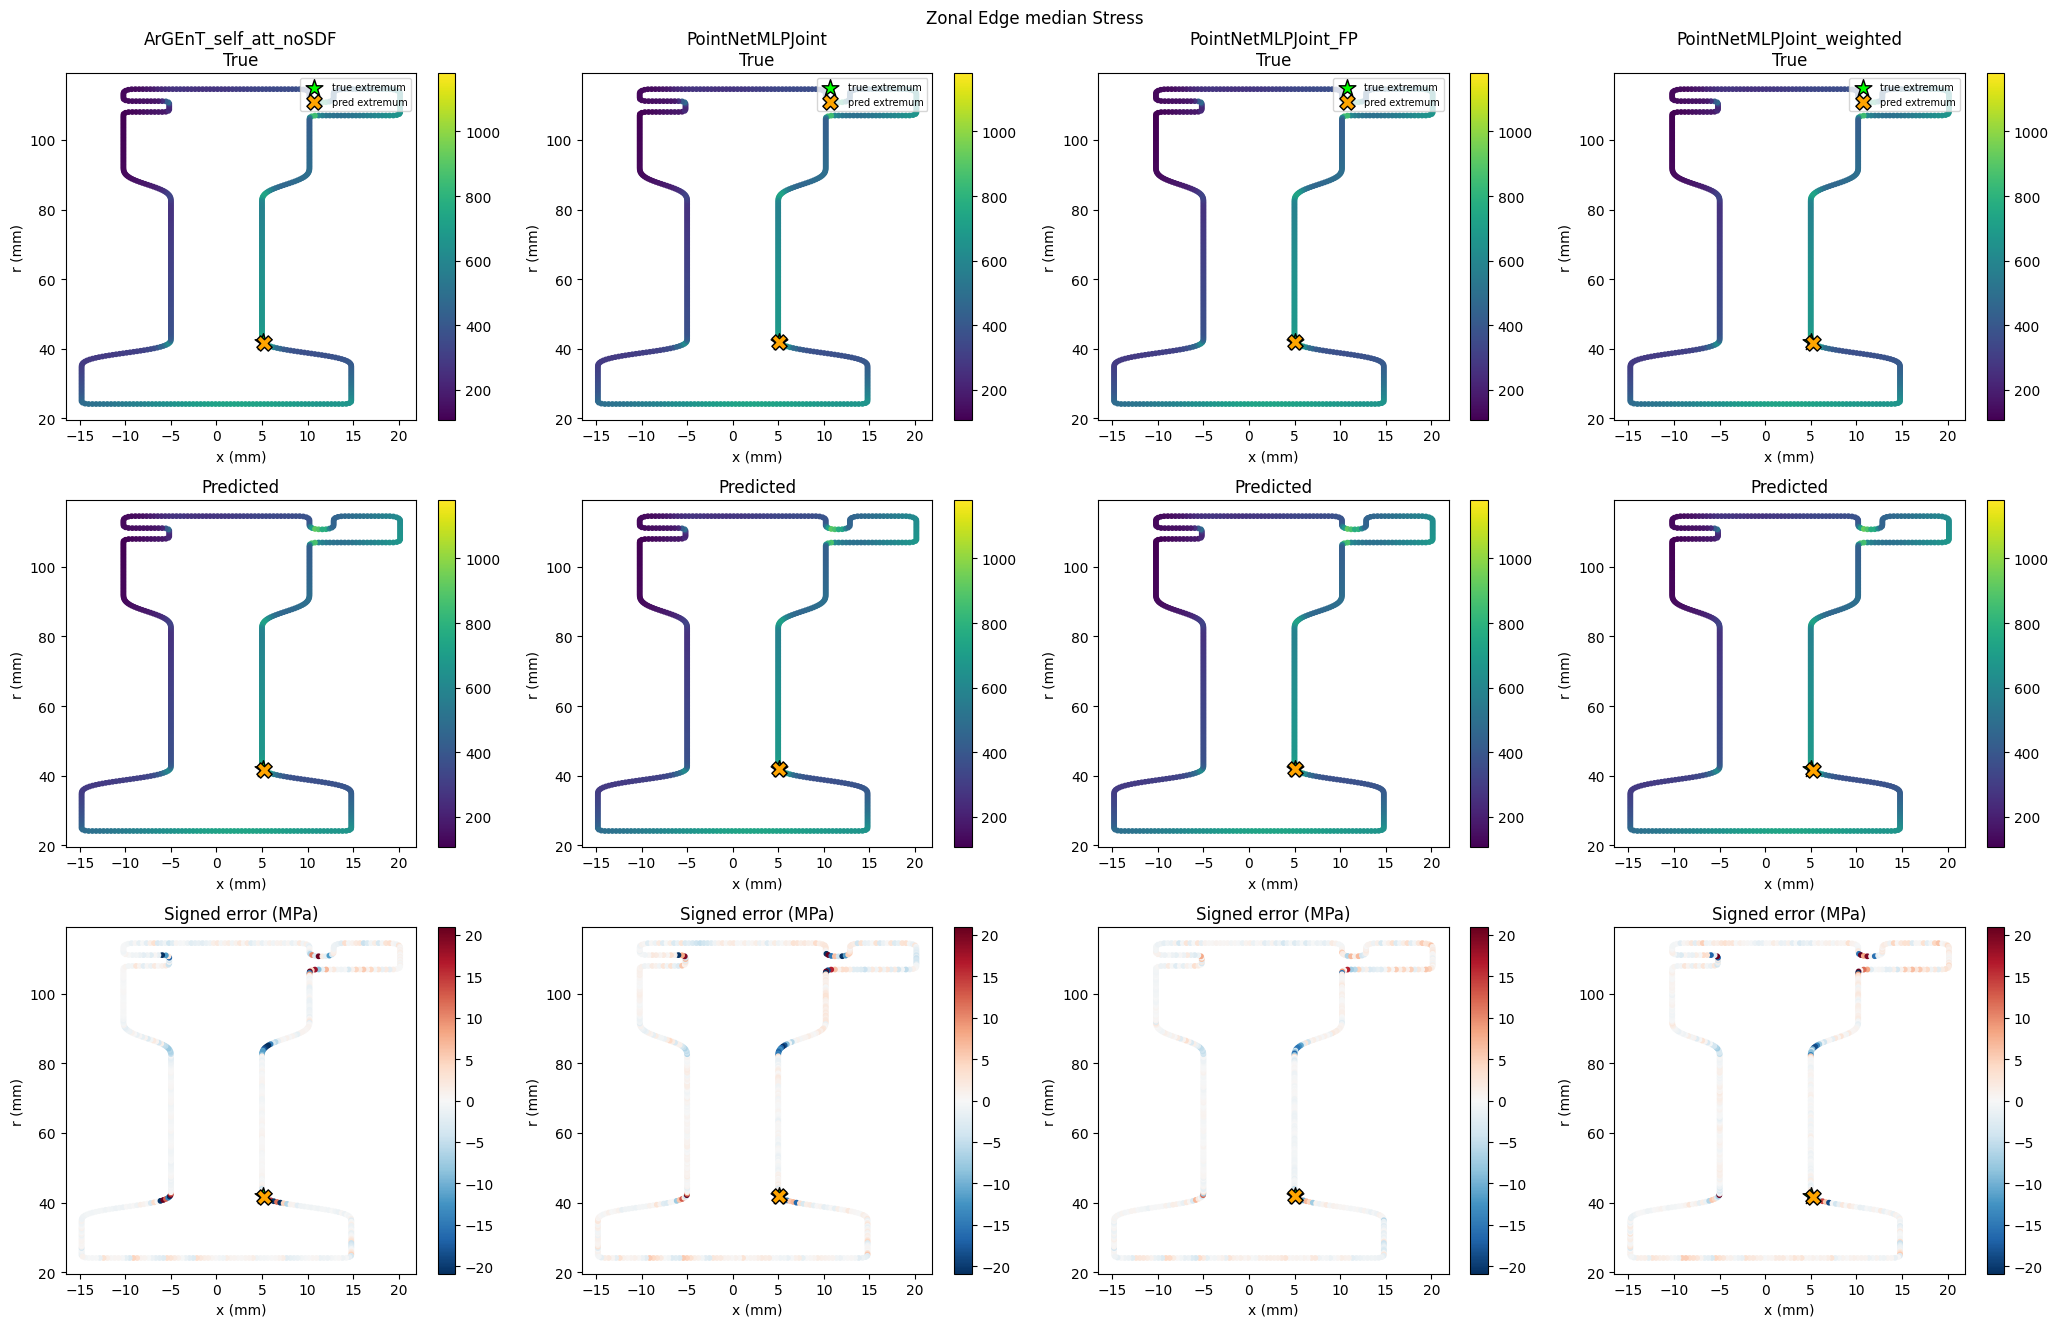

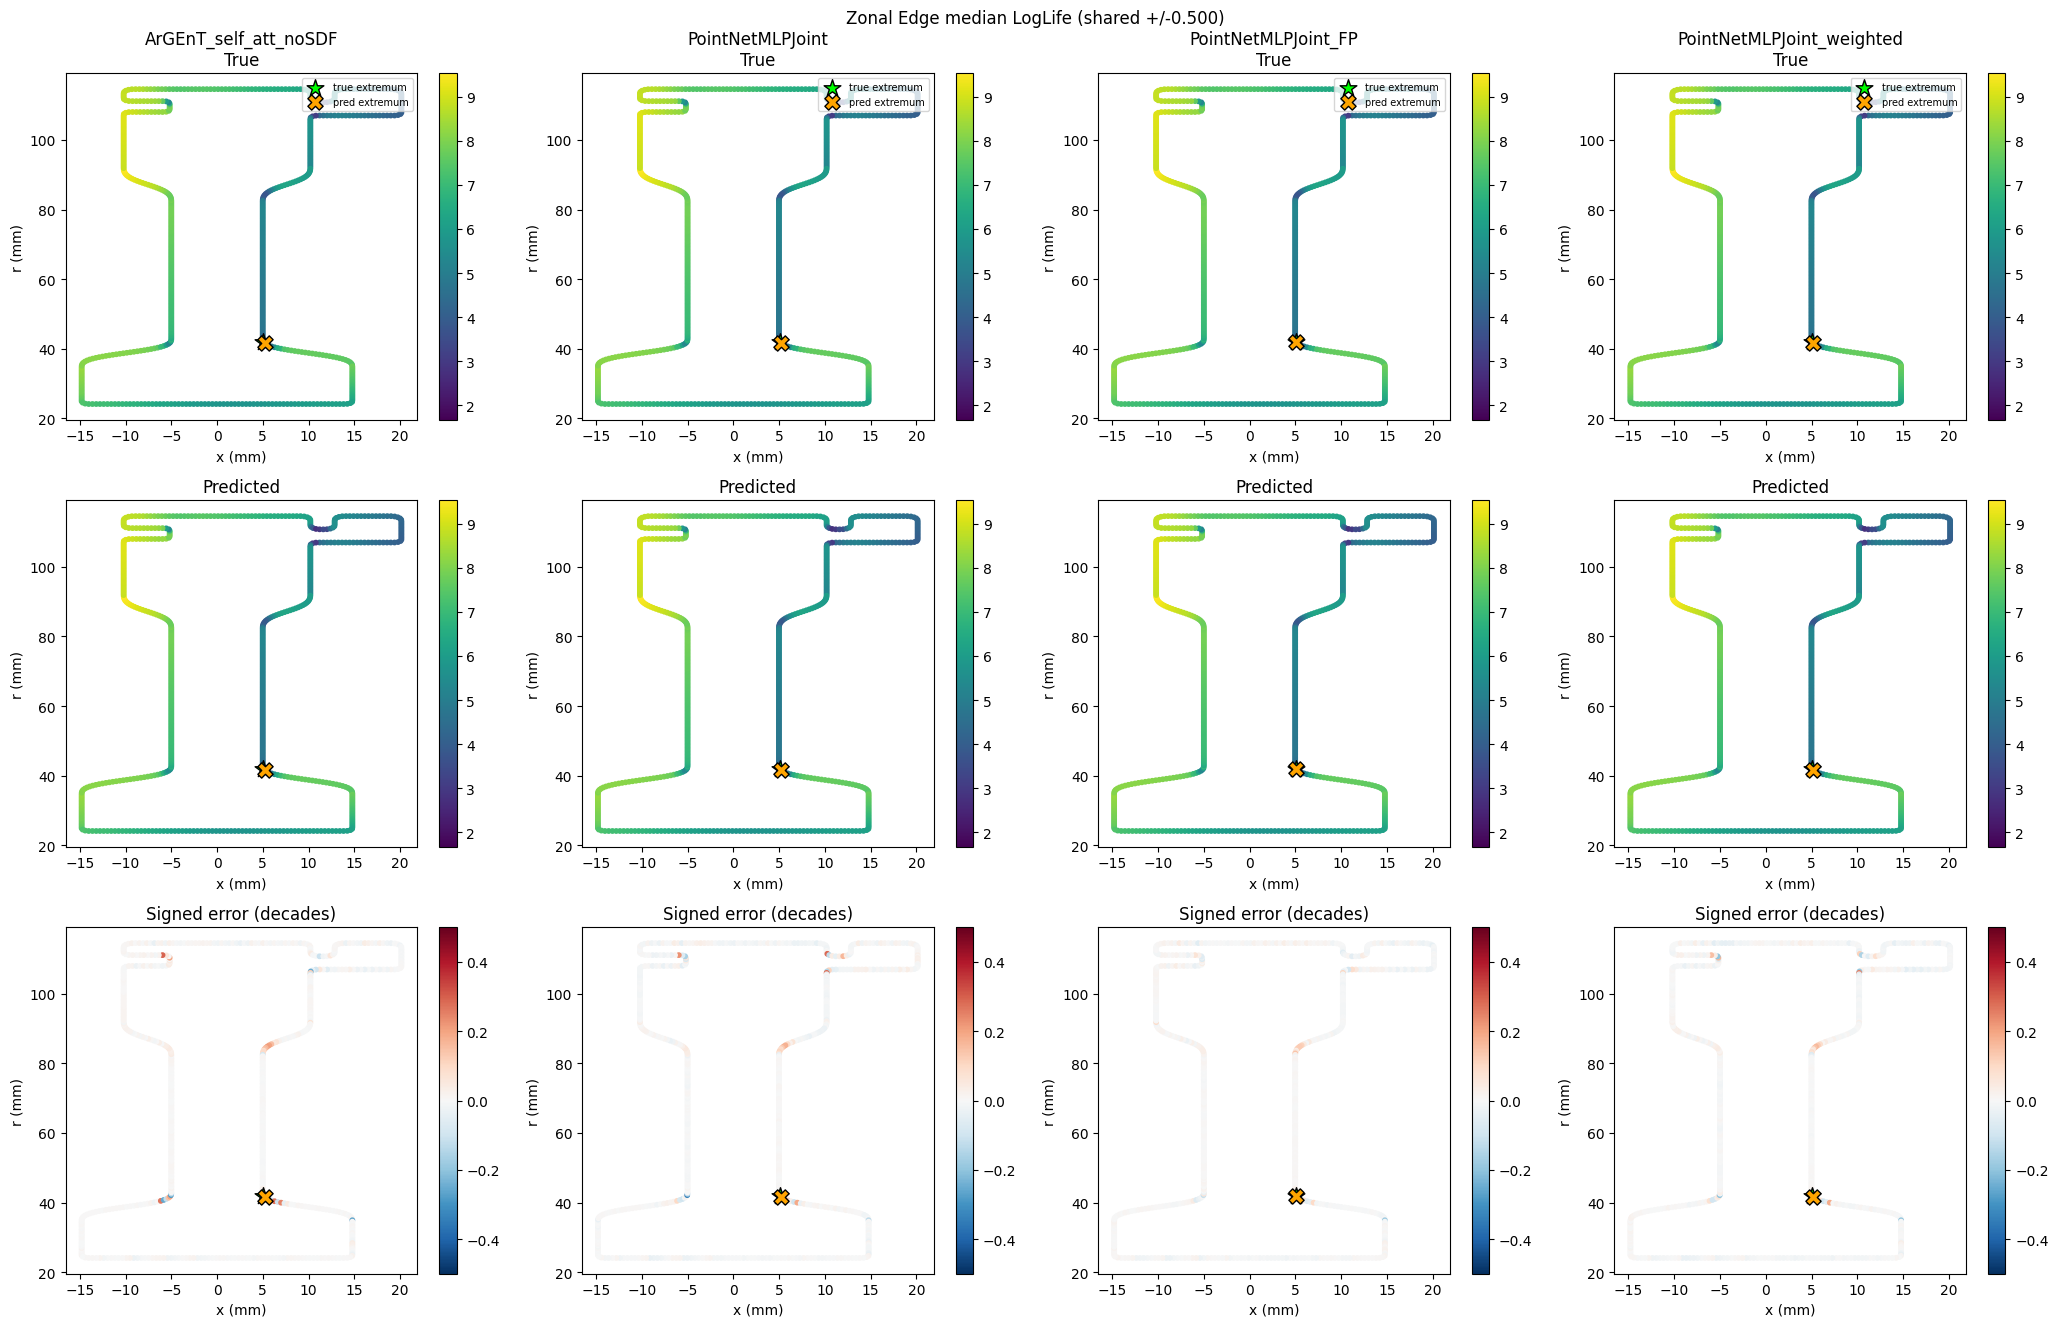

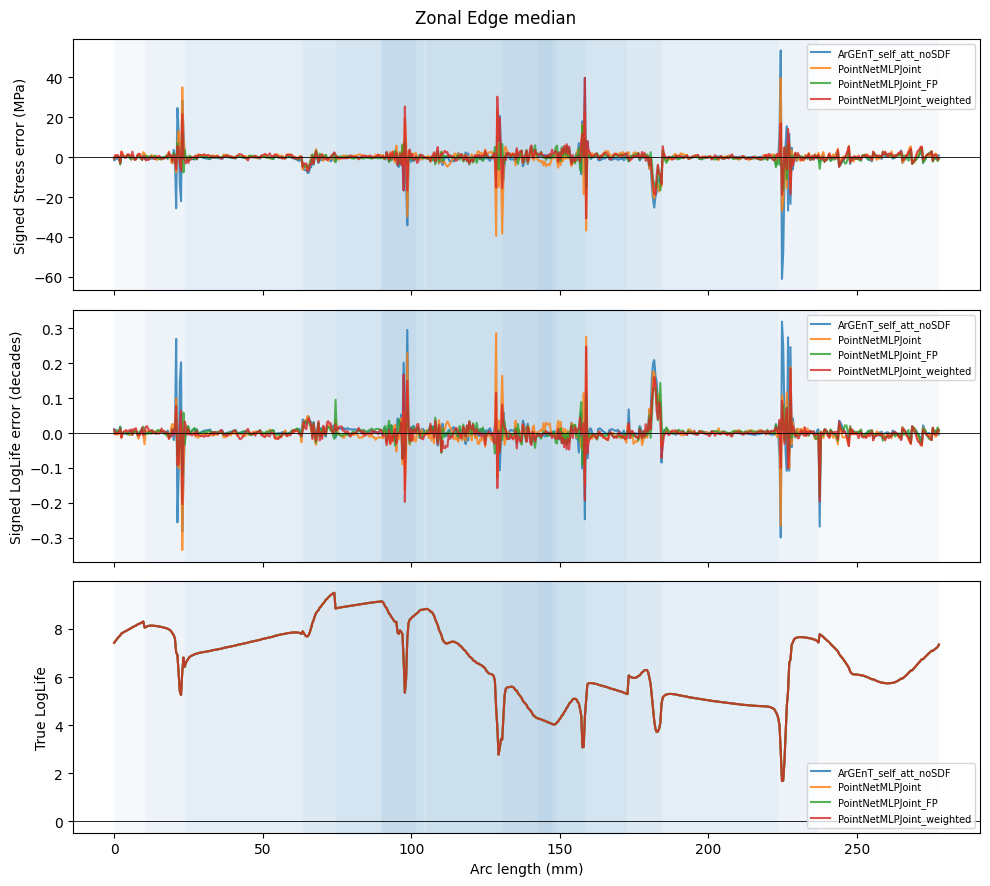

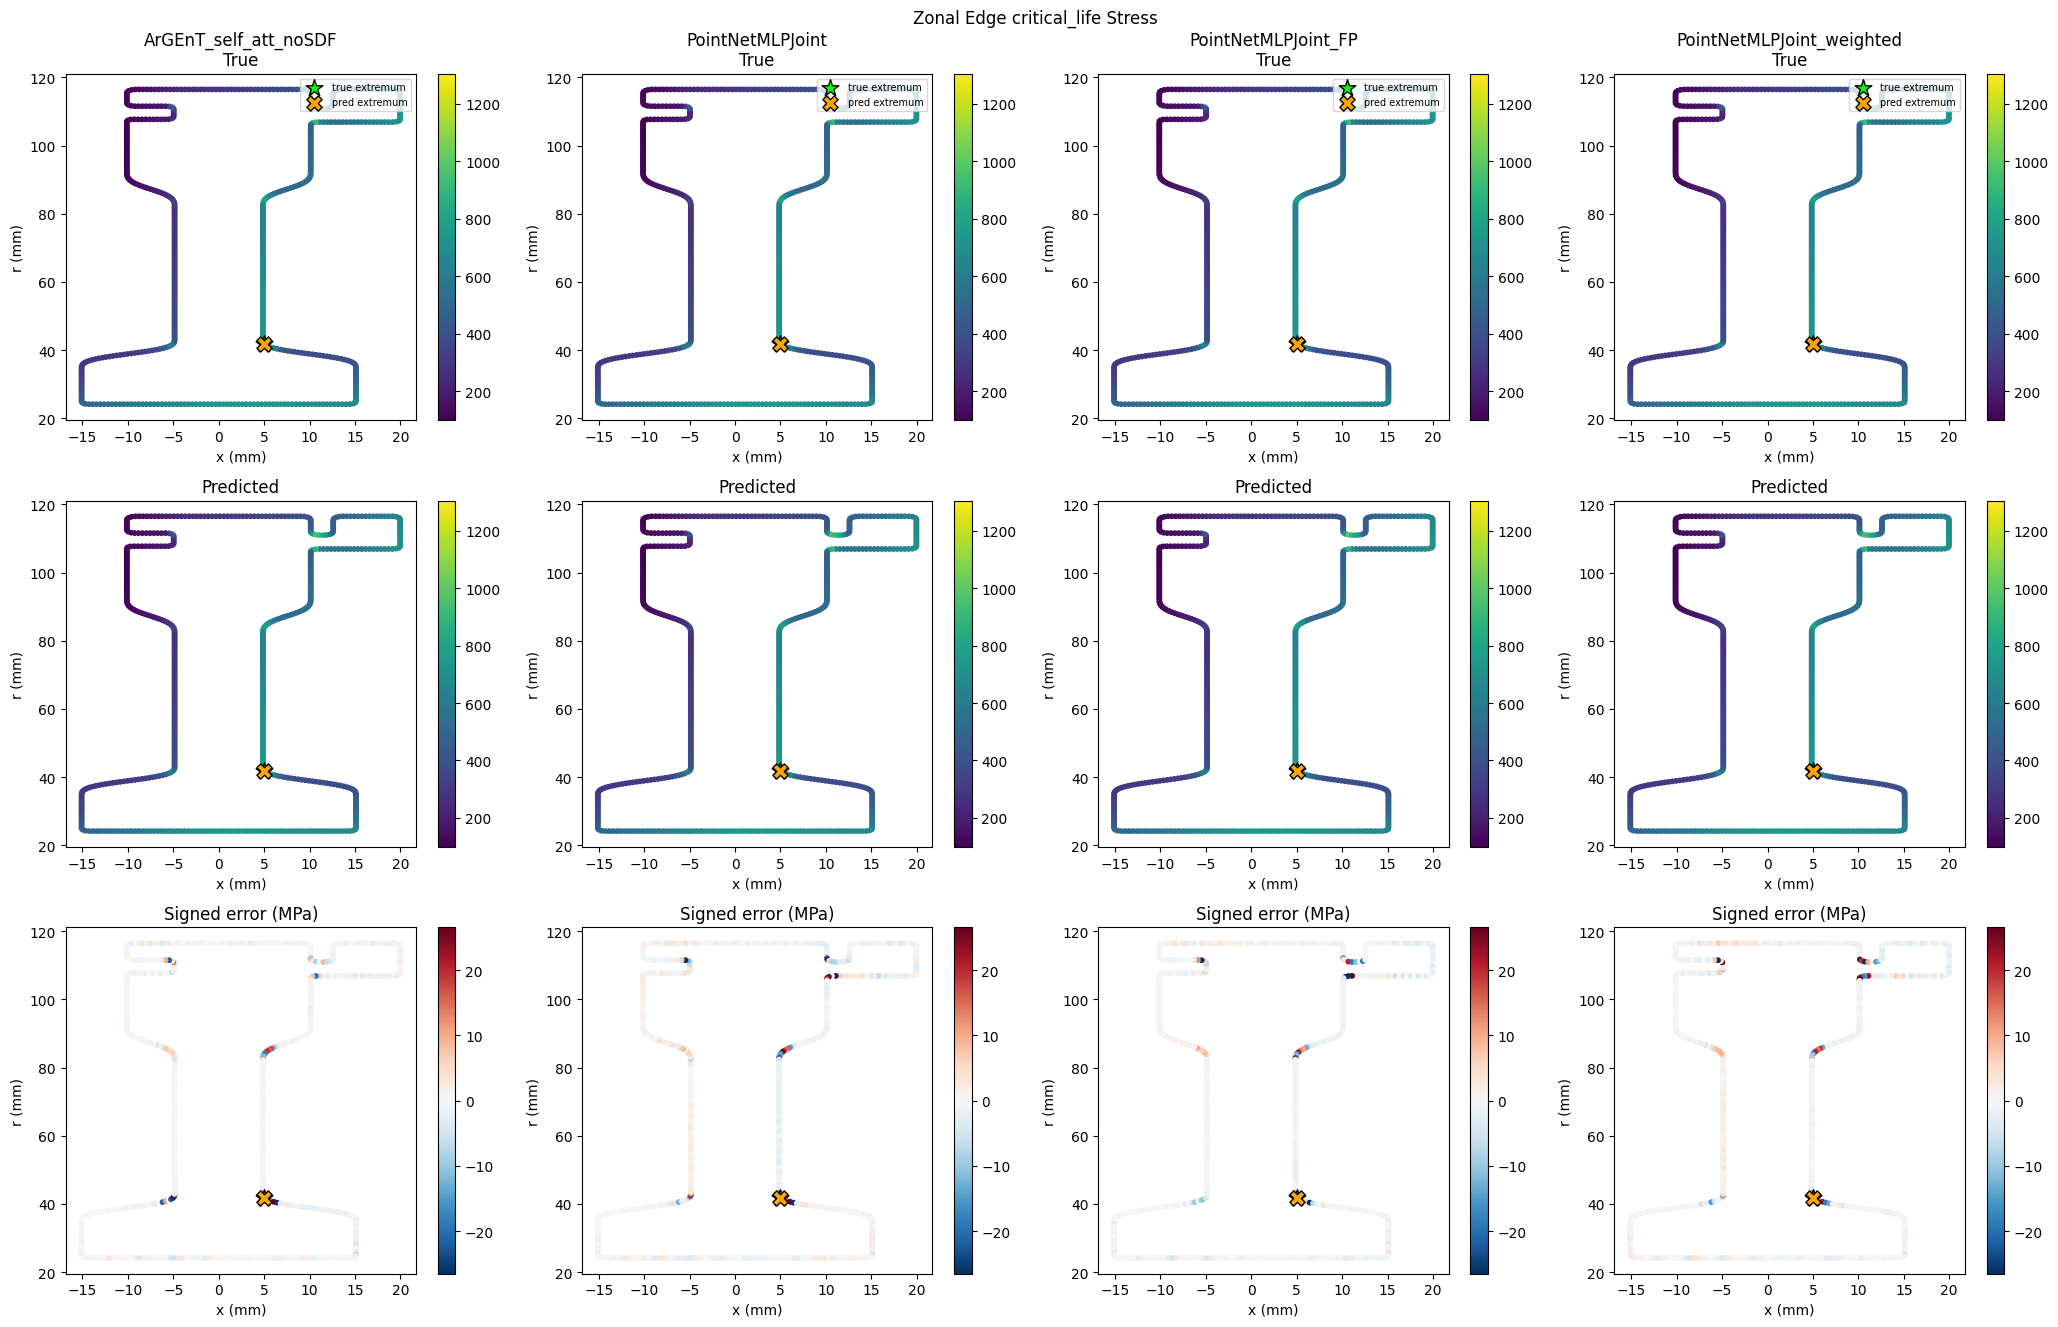

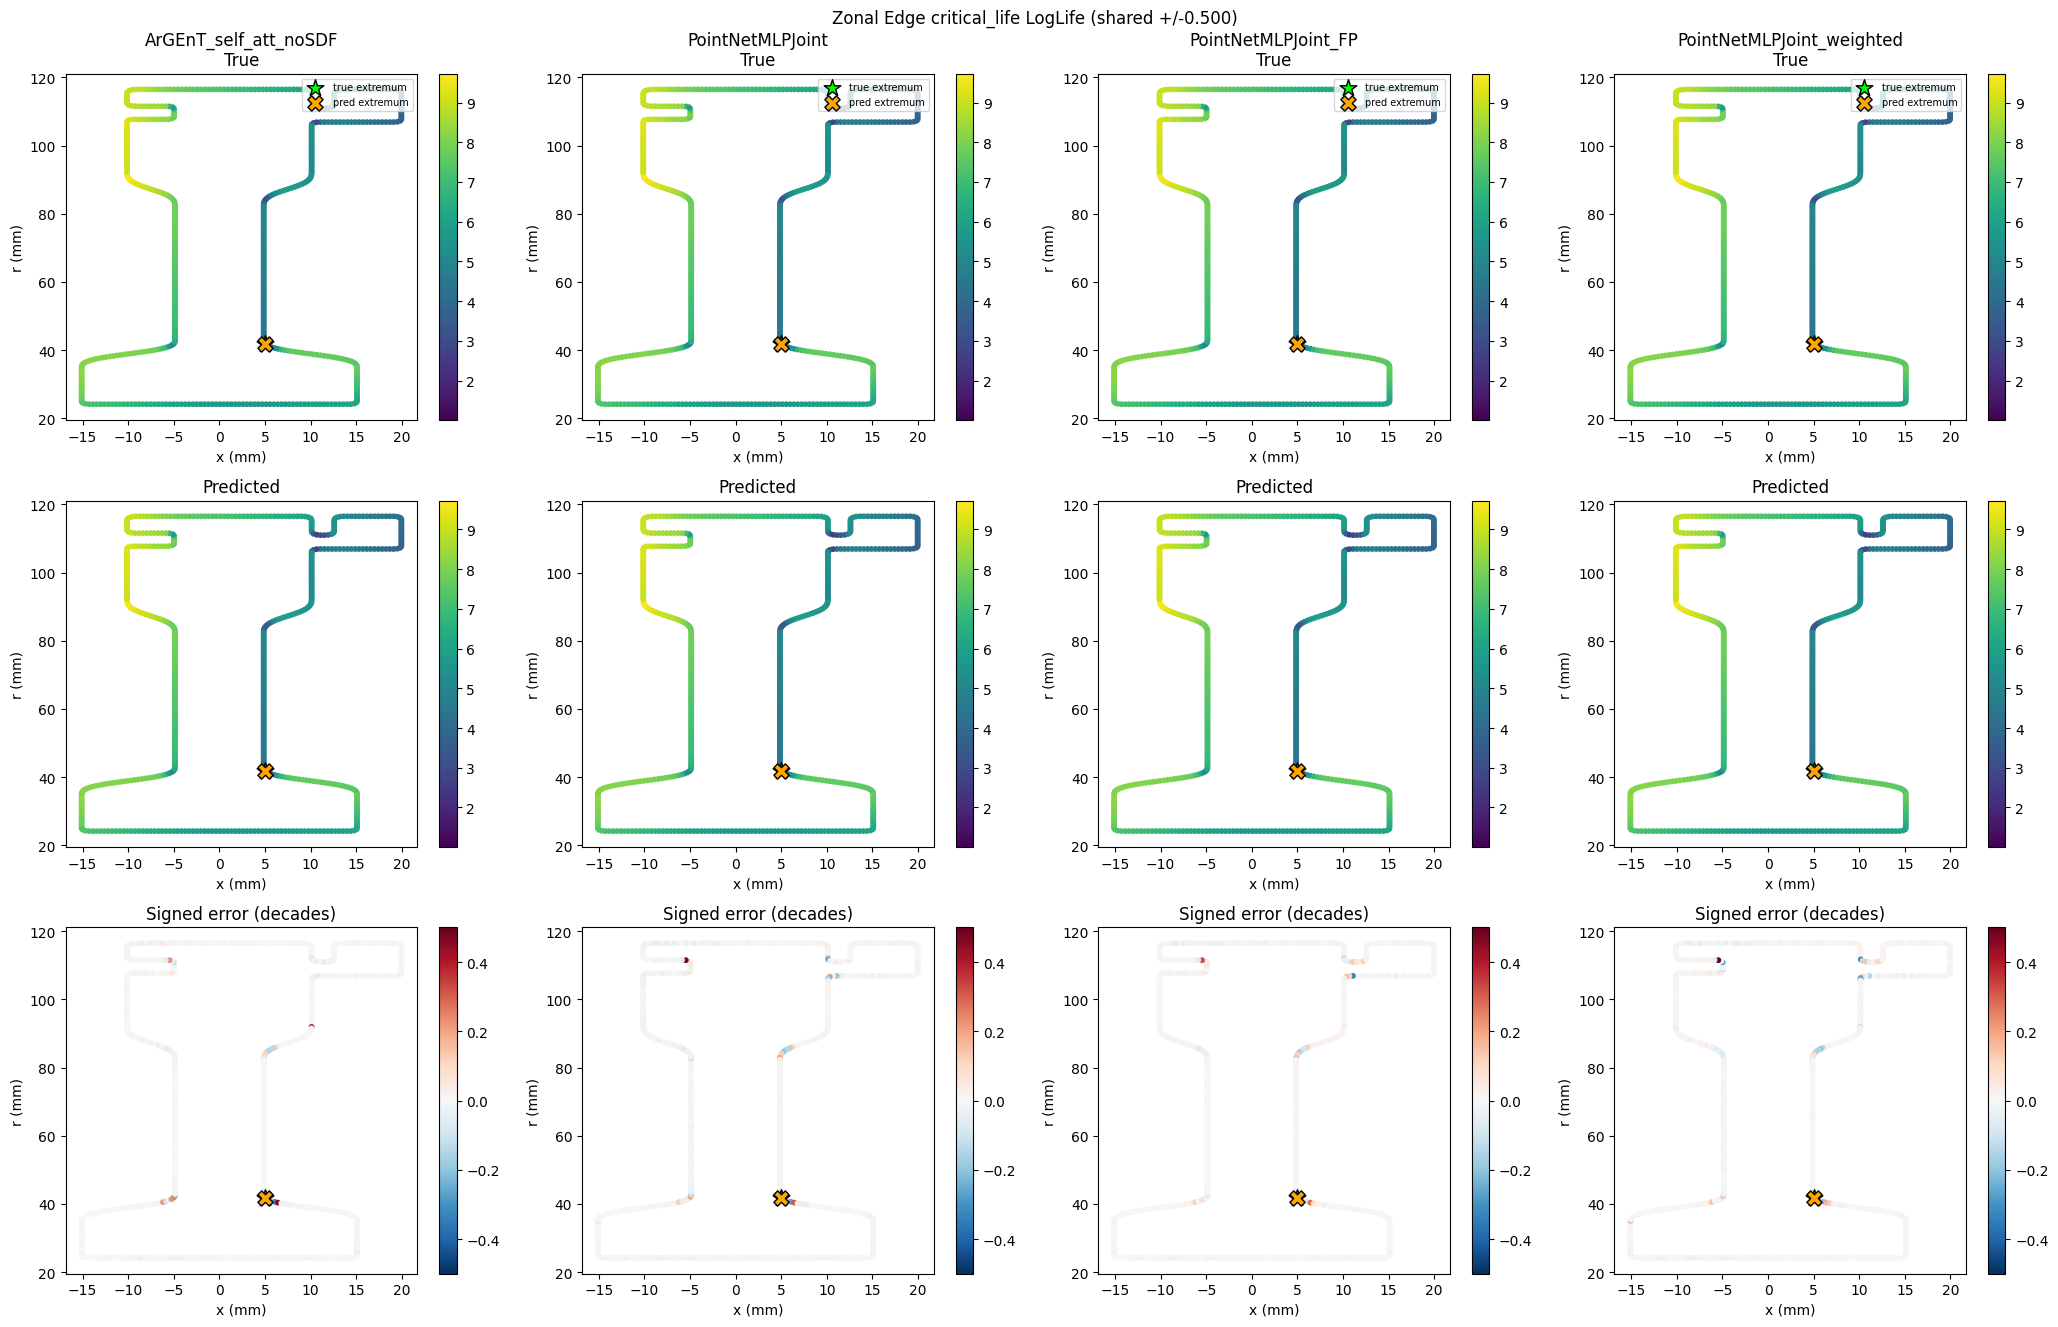

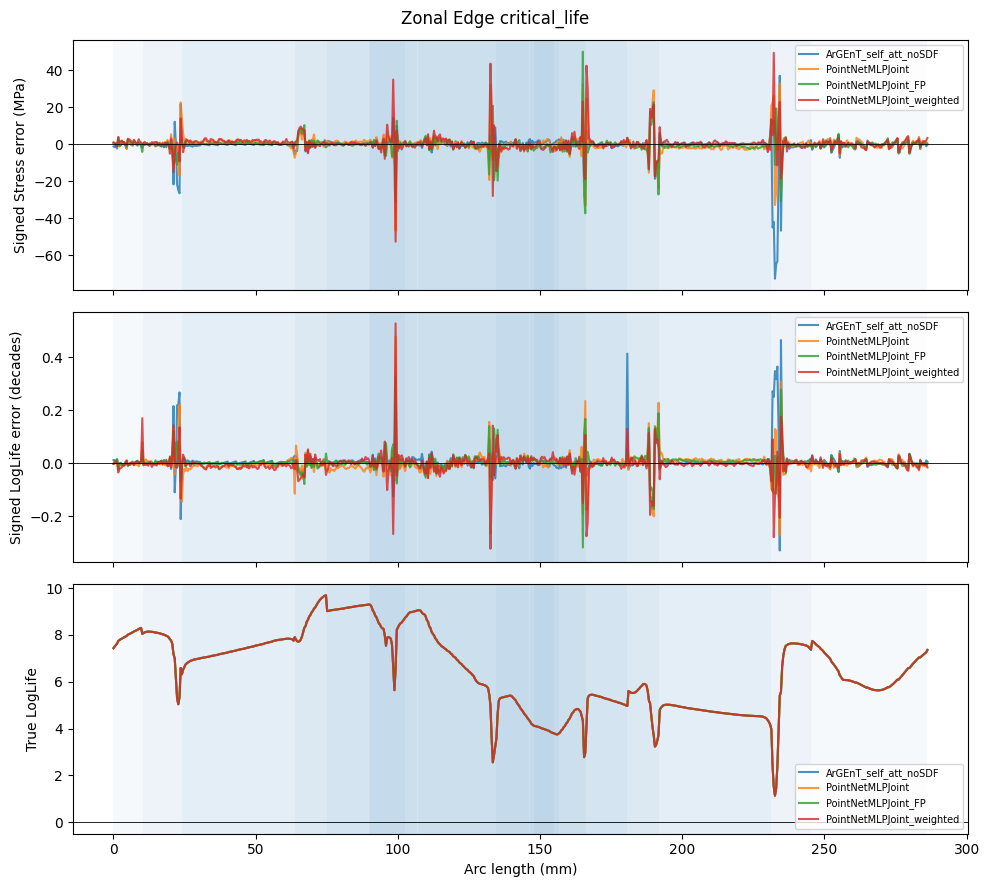

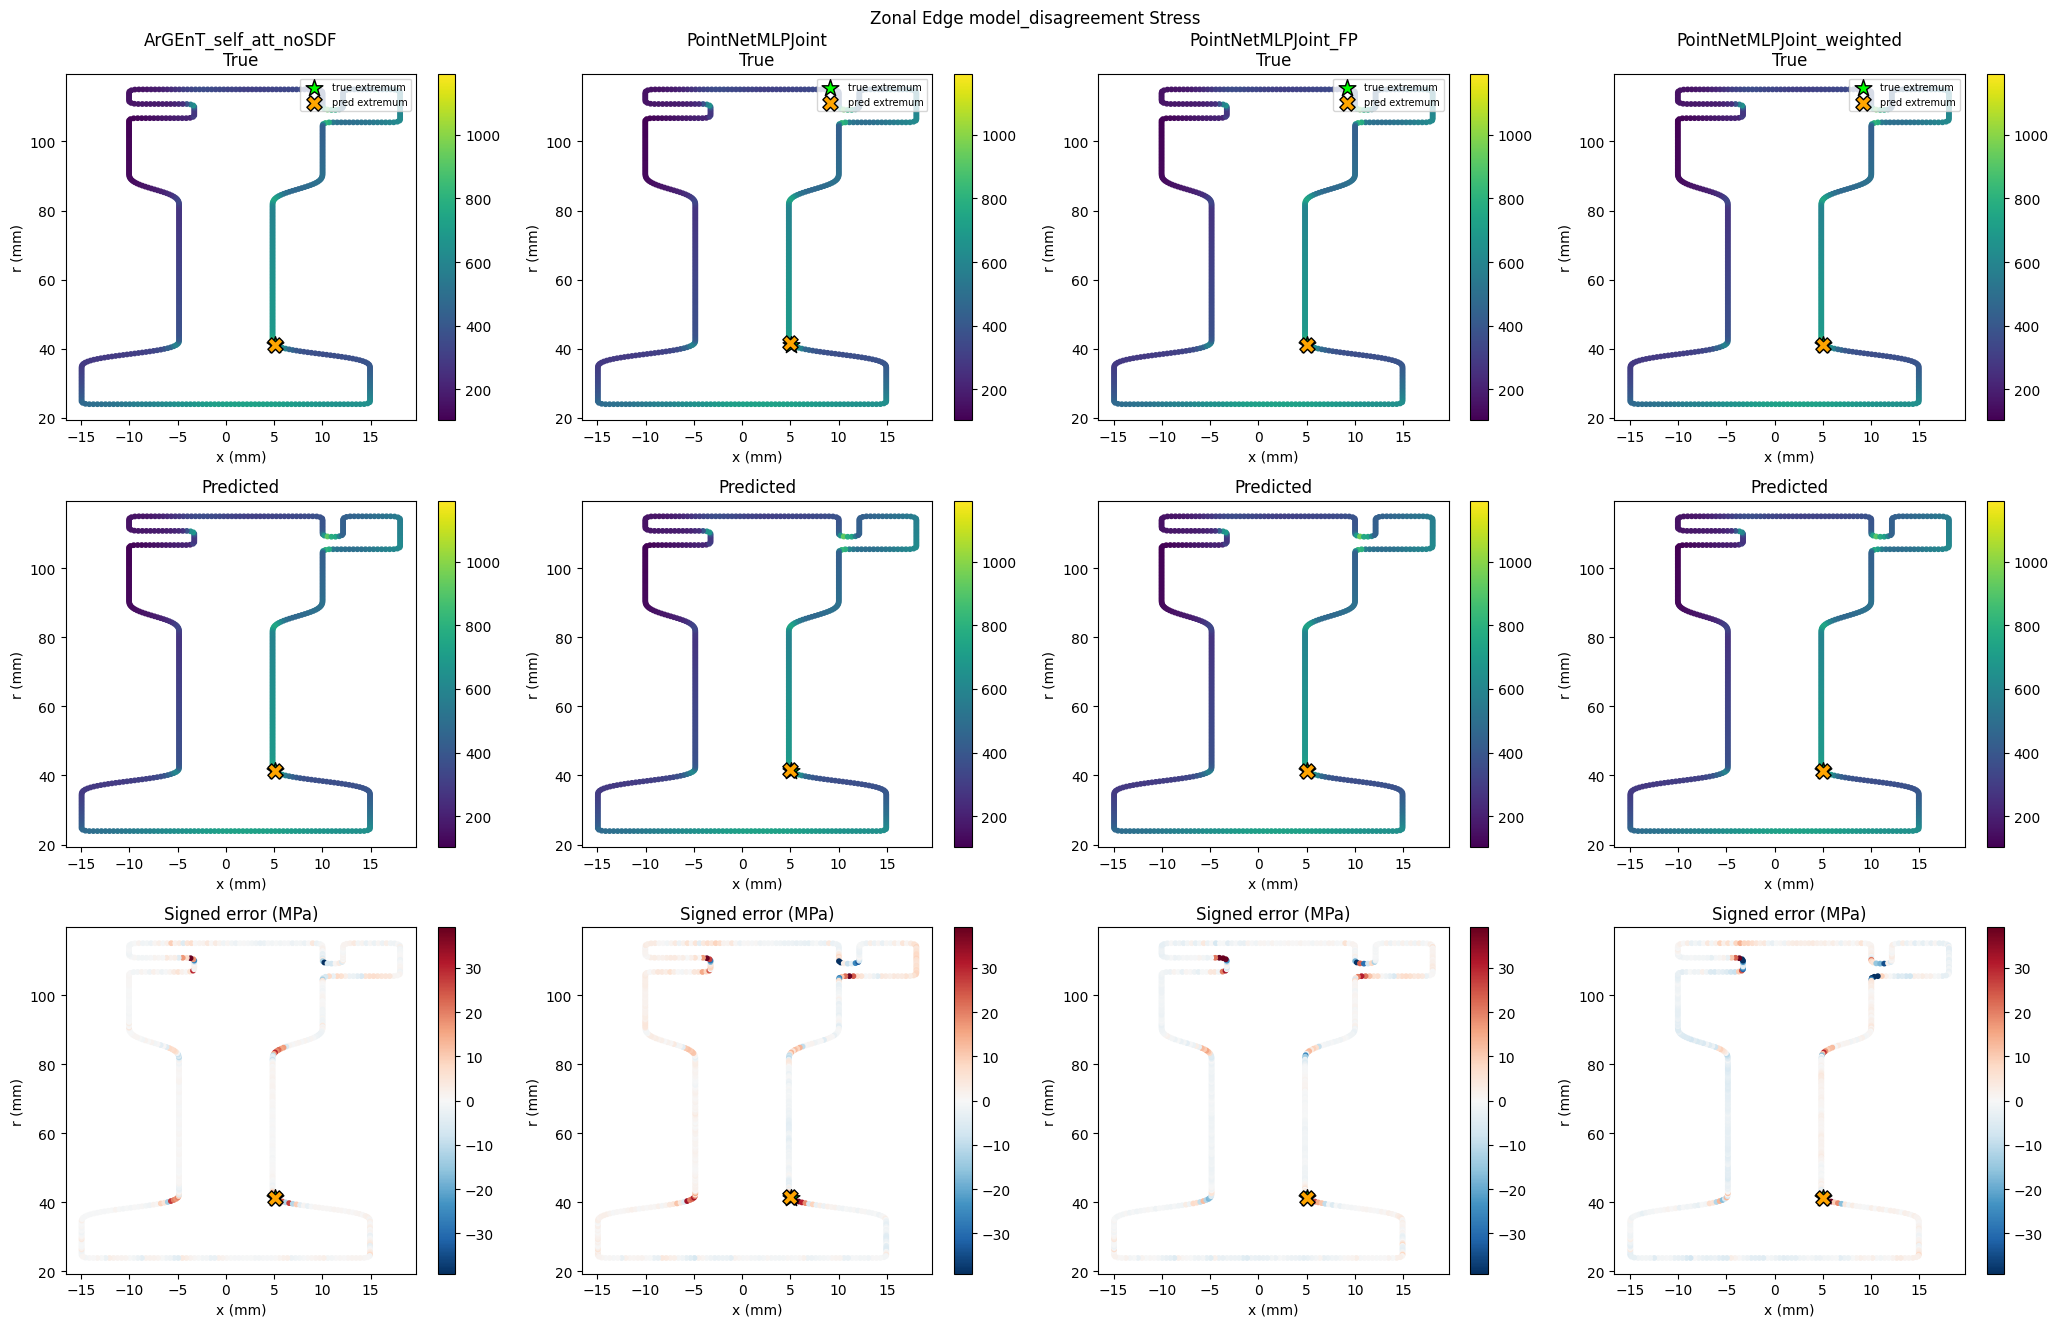

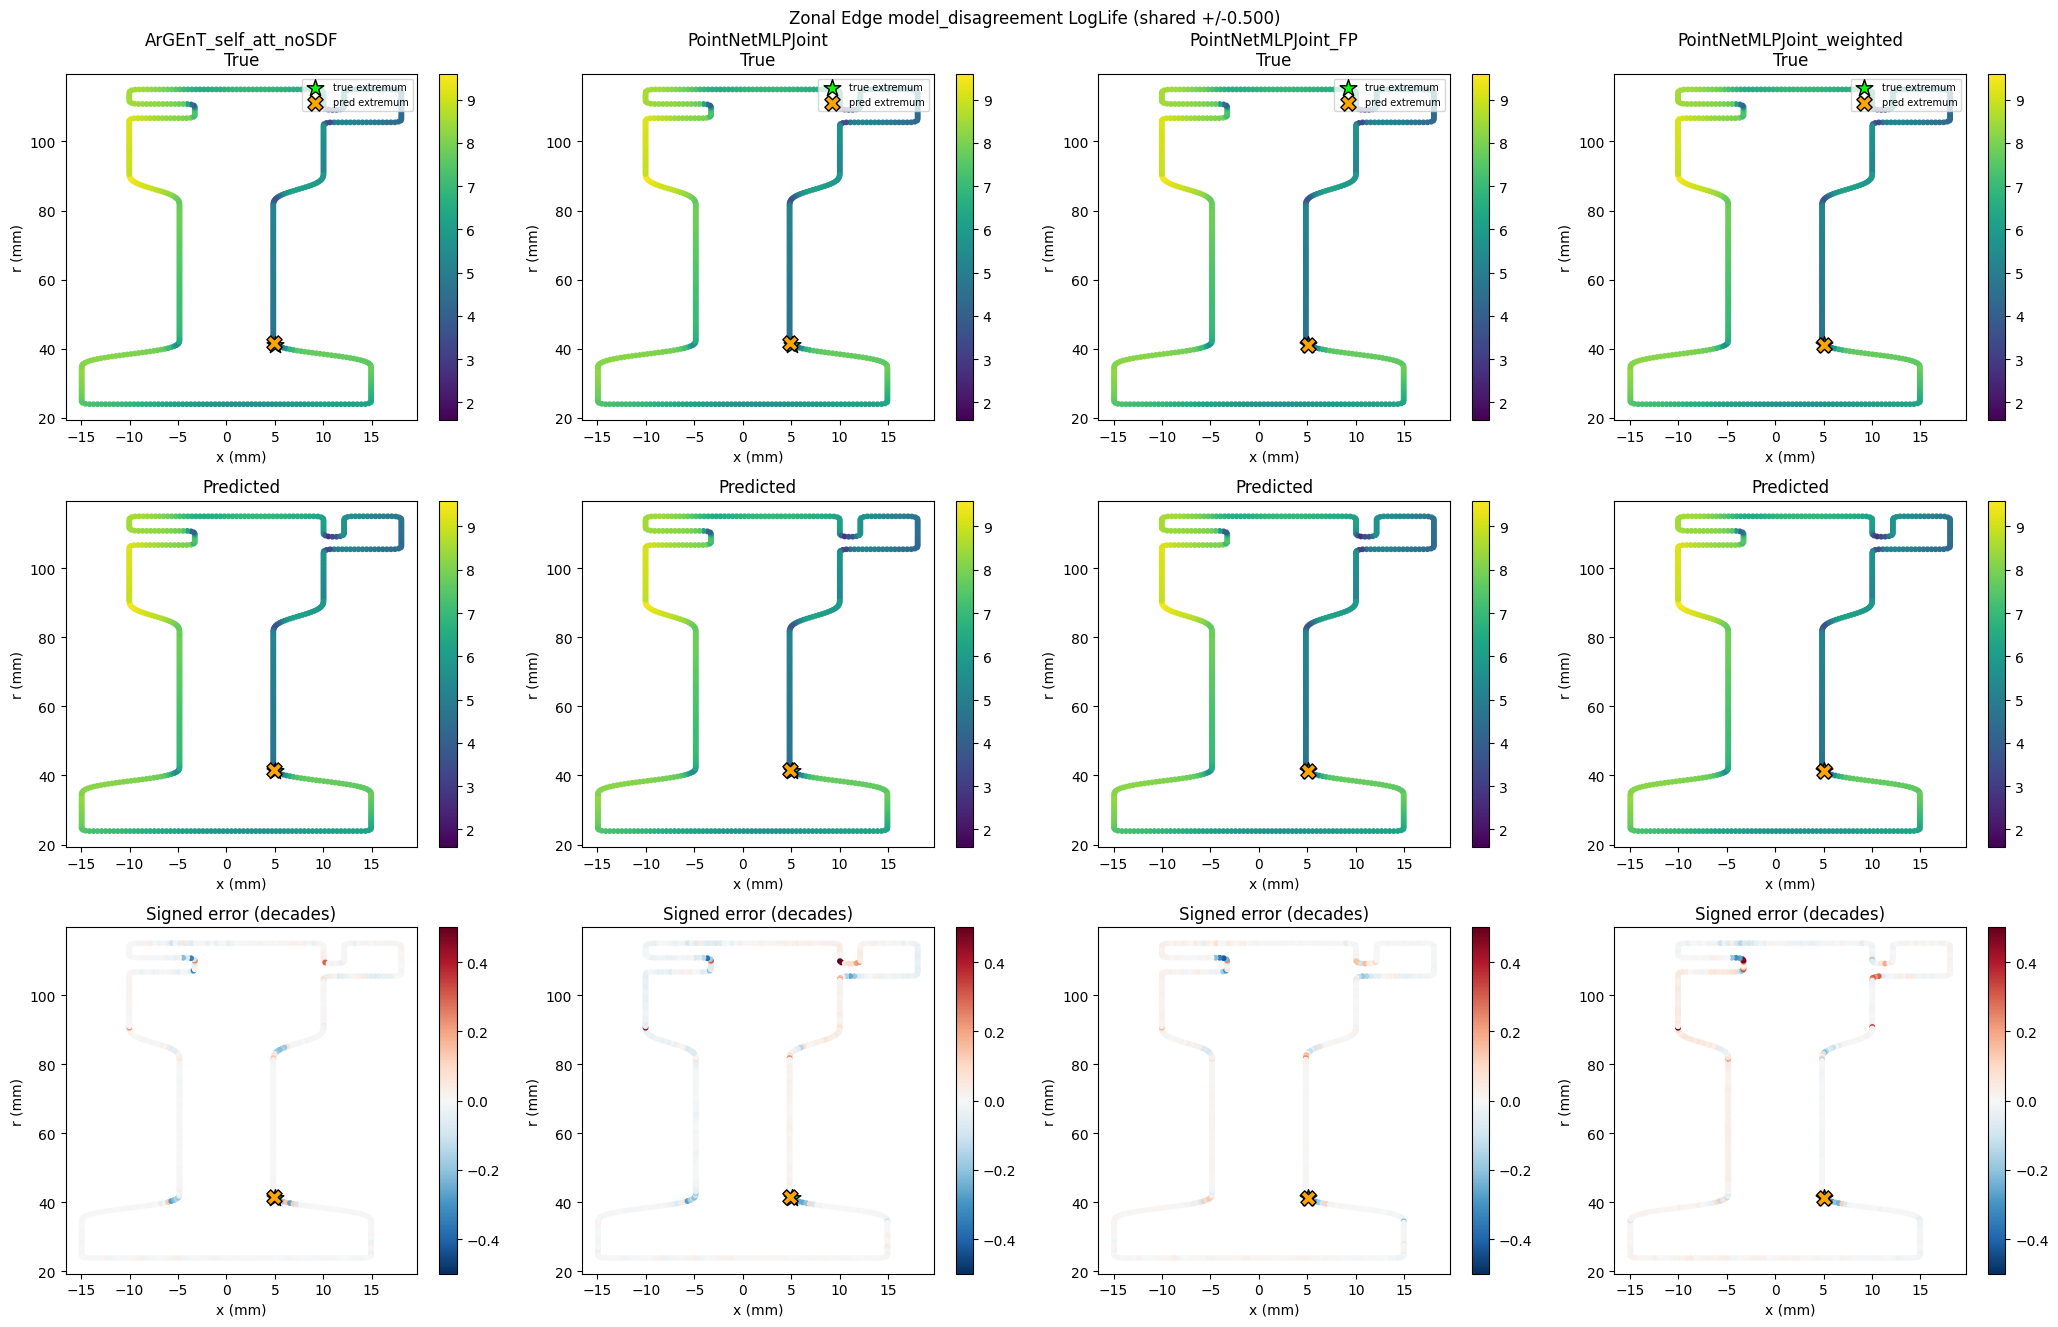

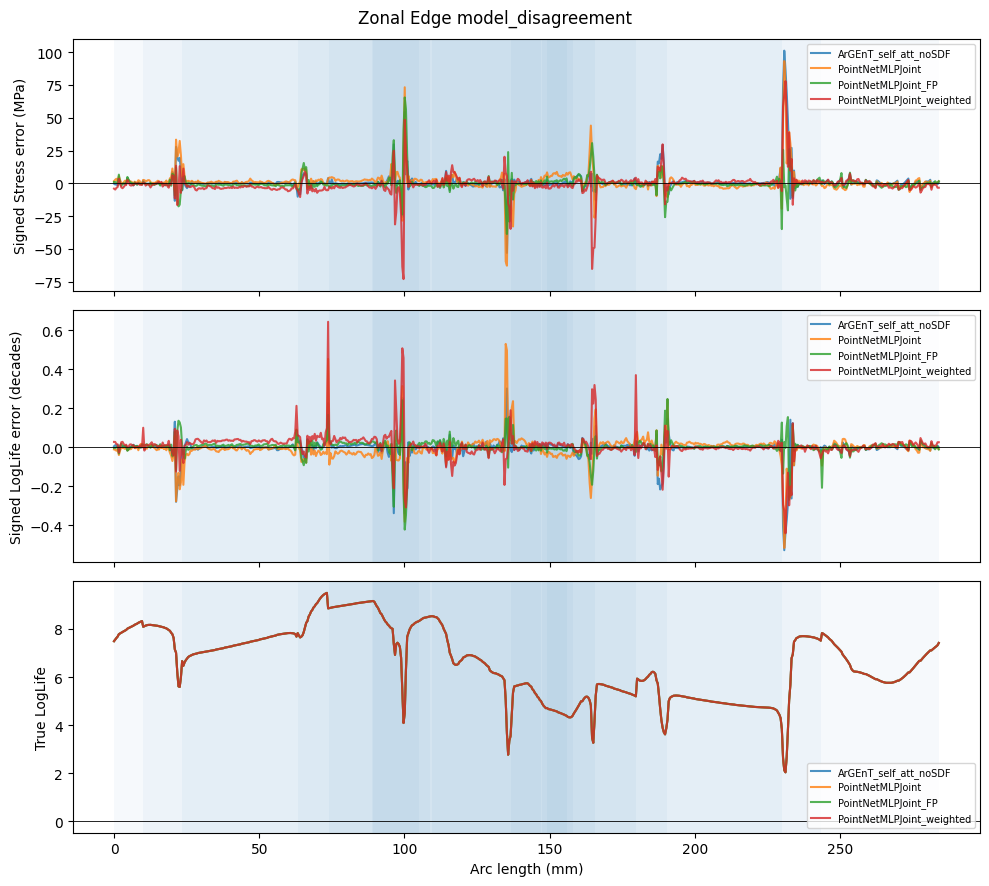

In [36]:
zonal=critical[critical.regime.eq('Zonal')]; zonal_models=zonal[zonal.model_family.isin(PRINCIPAL)]
shared=set(zonal_models.sample_id.astype(str).unique())
for family in zonal_models.model_family.unique(): shared &= set(zonal_models[zonal_models.model_family.eq(family)].sample_id.astype(str).unique())
shared=sorted(shared)
if len(shared)<3: raise RuntimeError(f'Fewer than three shared compatible Zonal representatives: {len(shared)}')
by_id=zonal_models[zonal_models.sample_id.astype(str).isin(shared)].groupby(zonal_models[zonal_models.sample_id.astype(str).isin(shared)].sample_id.astype(str))
joint=by_id.apply(lambda g: float(np.mean(np.abs(g.absolute_min_loglife_error_decades-g.absolute_min_loglife_error_decades.mean())+np.abs(g.absolute_max_stress_error_mpa-g.absolute_max_stress_error_mpa.mean()))))
median_id=str((joint-joint.median()).abs().idxmin()); critical_id=str(zonal_models.groupby(zonal_models.sample_id.astype(str)).true_min_loglife.first().idxmin())
a=zonal_models[zonal_models.model_family.eq('ArGEnT_self_att_noSDF')].assign(_sid=zonal_models.sample_id.astype(str)).set_index('_sid').absolute_min_loglife_error_decades; f=zonal_models[zonal_models.model_family.eq('PointNetMLPJoint_FP')].assign(_sid=zonal_models.sample_id.astype(str)).set_index('_sid').absolute_min_loglife_error_decades; disagreement_id=str((a.loc[shared]-f.loc[shared]).abs().idxmax())
reps={'median':median_id,'critical_life':critical_id,'model_disagreement':disagreement_id}
rep_rows=[]
for label,sid in reps.items():
    g=zonal_models[zonal_models.sample_id.astype(str).eq(str(sid))]; true=g.iloc[0]; sample=next(s for s in all_samples['Zonal'] if s['sample_id']==str(sid)); row={'selection':label,'sample_id':sid,'true_min_loglife':float(true.true_min_loglife),'true_min_life_cycles':float(10**true.true_min_loglife),'true_max_stress_mpa':float(true.true_max_stress),'governing_zone':true.true_critical_zone,'governing_subzone':true.true_critical_subzone,'geometry_attributes':sample.get('attrs',{})}
    for _,m in g.iterrows(): row[m.model_family+'_signed_min_loglife_error']=float(m.signed_min_loglife_error_decades); row[m.model_family+'_absolute_min_loglife_error']=float(m.absolute_min_loglife_error_decades); row[m.model_family+'_absolute_max_stress_error_mpa']=float(m.absolute_max_stress_error_mpa)
    rep_rows.append(row)
with open(RESULTS_DIR/'principal_representative_geometry_ids.json','w') as stream: json.dump({'evaluation_label':'validation-split evaluation','representatives':rep_rows},stream,indent=2,default=str)
for label,sid in reps.items():
    by_model={fam:nodes[(nodes.regime=='Zonal')&(nodes.sample_id.astype(str)==str(sid))&(nodes.model_family==fam)] for fam in zonal_models.model_family.unique()}; by_model={fam:d for fam,d in by_model.items() if not d.empty}
    eh.plot_field_comparison(by_model,'true_stress','pred_stress','MPa',f'Zonal Edge {label} Stress',mark_extrema='max',out_dir=FIGURES_DIR,filename=f'zonal_{label}_stress')
    life_limit=max(0.5,eh.robust_signed_limit([d.pred_loglife.to_numpy()-d.true_loglife.to_numpy() for d in by_model.values()]))
    eh.plot_field_comparison(by_model,'true_loglife','pred_loglife','decades',f'Zonal Edge {label} LogLife (shared +/-{life_limit:.3f})',fixed_error_limit=life_limit,mark_extrema='min',out_dir=FIGURES_DIR,filename=f'zonal_{label}_loglife')
    eh.plot_arc_length_error(by_model,f'Zonal Edge {label}',FIGURES_DIR,f'zonal_{label}_arc_length')
display(pd.DataFrame(rep_rows)[['selection','sample_id','true_min_loglife','true_min_life_cycles','true_max_stress_mpa','governing_zone','governing_subzone']])

## Automated critical-region conclusions

The following report is generated from the same **validation-split evaluation** predictions and records pooled, low-life, subzone, geometry-level, paired, and localisation findings.

In [37]:
def _verdict(pair, metric='paired_min_loglife_difference'):
    if pair.empty: return 'not determined (no compatible shared geometries)'
    median=float(pair[metric].median()); fraction=float((pair[metric]>0).mean())
    return f'helps (median paired difference {median:.5f}; better on {fraction:.1%} of shared geometries)' if median>0 and fraction>.5 else f'does not consistently help (median paired difference {median:.5f}; better on {fraction:.1%})'
summary_lines=[f'# Critical-region model comparison summary\n\nRepository commit: `{COMMIT}`\n\nEvaluation label: **validation-split evaluation**. The 80/20 geometry split uses seed 42; independence from training, validation, early stopping, checkpoint selection, and hyperparameter selection is not proved.']
summary_lines.append('\n## Compatibility\n\n'+checkpoint_report[['regime','model_family','status','checkpoint_path']].to_markdown(index=False))
summary_lines.append('\n## Selected Zonal representatives\n\n'+pd.DataFrame(rep_rows)[['selection','sample_id','true_min_loglife','true_min_life_cycles','true_max_stress_mpa','governing_zone','governing_subzone']].to_markdown(index=False))
for regime in ['Uniform','Zonal']:
    p=pooled[pooled.regime.eq(regime)]; b=bins[bins.regime.eq(regime)]; z=zones[zones.regime.eq(regime)]; g=critical[critical.regime.eq(regime)]
    rp=_paired(g,'PointNetMLPJoint','PointNetMLPJoint_FP'); ra=_paired(g,'ArGEnT_self_att_noSDF','PointNetMLPJoint_FP'); rw=_paired(g,'PointNetMLPJoint','PointNetMLPJoint_weighted')
    summary_lines.append(f'\n## {regime} results\n\nPooled metrics:\n\n{p.to_markdown(index=False)}')
    summary_lines.append(f'\nLow-life bins:\n\n{b.to_markdown(index=False)}')
    summary_lines.append(f'\nLower-transition and subzone metrics:\n\n{z[z.subzone_name.eq("lower_transition")].to_markdown(index=False)}')
    summary_lines.append(f'\nGeometry-level critical summary:\n\n{critical_summary[critical_summary.regime.eq(regime)].to_markdown(index=False)}')
    summary_lines.append(f'\nFP versus regular PointNet: {_verdict(pairs["regular_vs_fp"] if regime=="Zonal" else rp)}. FP versus ArGEnT: {_verdict(pairs["argent_vs_fp"] if regime=="Zonal" else ra)}.')
    summary_lines.append(f' Weighted versus regular PointNet: {_verdict(pairs["regular_vs_weighted"] if regime=="Zonal" else rw)}.')
summary_lines.append('\n## Interpretation and limitations\n\nFP improves pooled LogLife MAE and the available critical-region paired summaries in the reported data, but the conclusion is not universal and should be checked across bins, lower transition, localisation, and maximum stress. Pooled metrics and critical-region metrics can rank models differently. Raw-life MAPE/MPE/Max_PE are secondary diagnostics; raw-life Max_PE can be dominated by small true-life values. These are validation-split diagnostics, not independent test performance or certification evidence. Weighted-loss conclusions are based on paired critical metrics and do not assume LogLife-only weighting without code/checkpoint evidence.')
critical_summary_text='\n'.join(summary_lines); (RESULTS_DIR/'critical_region_summary.md').write_text(critical_summary_text,encoding='utf-8'); display(Markdown(critical_summary_text))

# Critical-region model comparison summary

Repository commit: `ae6197d15a5a23c99f72ca45fd14f3cfb8e66df5`

Evaluation label: **validation-split evaluation**. The 80/20 geometry split uses seed 42; independence from training, validation, early stopping, checkpoint selection, and hyperparameter selection is not proved.

## Compatibility

| regime   | model_family              | status     | checkpoint_path                                                                                                                  |
|:---------|:--------------------------|:-----------|:---------------------------------------------------------------------------------------------------------------------------------|
| Uniform  | ArGEnT_self_att_noSDF     | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt    |
| Uniform  | PointNetMLPJoint          | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_78193d0f.pt          |
| Uniform  | PointNetMLPJoint_FP       | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\PointNetMLPJoint_FP\Trained_models\pnmlp_16932d84.pt                    |
| Uniform  | PointNetMLPJoint_weighted | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Uniform\Edge\PointNetMLPJoint_weighted\Trained_models\pn_s_full_ln_pos12_78193d0f.pt |
| Zonal    | ArGEnT_self_att_noSDF     | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\ArGEnT_self_att_noSDF\Trained_models\argent_self_nosdf_s_177b264d.pt      |
| Zonal    | PointNetMLPJoint          | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\PointNetMLPJoint\Trained_models\pn_s_full_ln_pos12_78193d0f.pt            |
| Zonal    | PointNetMLPJoint_FP       | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\PointNetMLPJoint_FP\Trained_models\pnmlp_16932d84.pt                      |
| Zonal    | PointNetMLPJoint_weighted | discovered | c:\Users\abfat\Desktop\Disc_lifing_paper_v2\Zonal\Edge\PointNetMLPJoint_weighted\Trained_models\pn_s_full_ln_pos12_78193d0f.pt   |

## Selected Zonal representatives

| selection          |   sample_id |   true_min_loglife |   true_min_life_cycles |   true_max_stress_mpa | governing_zone   | governing_subzone   |
|:-------------------|------------:|-------------------:|-----------------------:|----------------------:|:-----------------|:--------------------|
| median             |        1716 |            1.67306 |                47.1044 |               1179.31 | lower_transition | lower_transition    |
| critical_life      |        2809 |            1.13825 |                13.7482 |               1296.48 | lower_transition | lower_transition    |
| model_disagreement |        2146 |            2.03746 |               109.007  |               1105.59 | lower_transition | lower_transition    |

## Uniform results

Pooled metrics:

| regime   | ablation   | model_family              | target   |          MSE |      RMSE |       MAE |   R2 (log) |   MAPE (%) |    MPE (%) |   Max_PE (%) |      RMSE_raw |   MSE_raw_life |   R2_raw_life |
|:---------|:-----------|:--------------------------|:---------|-------------:|----------:|----------:|-----------:|-----------:|-----------:|-------------:|--------------:|---------------:|--------------:|
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | LogLife  |  0.00113394  | 0.0336741 | 0.0137403 |   0.999429 |    3.22282 |   0.250998 |      1424.41 |   1.31083e+07 |    1.71828e+14 |      0.999404 |
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | Stress   | 36.7985      | 6.06617   | 2.04841   |   0.998906 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Uniform  | Edge       | PointNetMLPJoint          | LogLife  |  0.000888242 | 0.0298034 | 0.014685  |   0.999553 |    3.43521 |   0.592429 |      1417.72 |   2.12234e+07 |    4.50432e+14 |      0.998437 |
| Uniform  | Edge       | PointNetMLPJoint          | Stress   | 21.069       | 4.5901    | 2.02515   |   0.999374 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Uniform  | Edge       | PointNetMLPJoint_FP       | LogLife  |  0.000480881 | 0.021929  | 0.0105979 |   0.999758 |    2.46685 |   0.231972 |      3121.28 |   2.05032e+07 |    4.20382e+14 |      0.998541 |
| Uniform  | Edge       | PointNetMLPJoint_FP       | Stress   | 10.8539      | 3.29452   | 1.43805   |   0.999677 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Uniform  | Edge       | PointNetMLPJoint_weighted | LogLife  |  0.000861275 | 0.0293475 | 0.0143998 |   0.999566 |    3.34617 |   0.315118 |      2331.02 |   2.38367e+07 |    5.68188e+14 |      0.998028 |
| Uniform  | Edge       | PointNetMLPJoint_weighted | Stress   | 20.2414      | 4.49905   | 1.97708   |   0.999398 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |

Low-life bins:

| regime   | ablation   | model_family              | bin       |   n_nodes |         MAE |        RMSE |   signed_mean_error |   max_abs_error | unstable   |
|:---------|:-----------|:--------------------------|:----------|----------:|------------:|------------:|--------------------:|----------------:|:-----------|
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | all       |    679000 |   0.0137403 |   0.0336741 |        -0.00027612  |        1.1831   | False      |
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | LogLife<4 |      6280 |   0.12525   |   0.151409  |         0.0088143   |        0.507604 | False      |
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | LogLife<3 |      1414 |   0.155946  |   0.169619  |         0.0956192   |        0.437625 | False      |
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | LogLife<2 |         0 | nan         | nan         |       nan           |      nan        | True       |
| Uniform  | Edge       | PointNetMLPJoint          | all       |    679000 |   0.014685  |   0.0298034 |         0.00151263  |        1.39359  | False      |
| Uniform  | Edge       | PointNetMLPJoint          | LogLife<4 |      6280 |   0.0549738 |   0.0789244 |         0.00563482  |        1.18119  | False      |
| Uniform  | Edge       | PointNetMLPJoint          | LogLife<3 |      1414 |   0.0509933 |   0.0733406 |         0.0198922   |        0.453522 | False      |
| Uniform  | Edge       | PointNetMLPJoint          | LogLife<2 |         0 | nan         | nan         |       nan           |      nan        | True       |
| Uniform  | Edge       | PointNetMLPJoint_FP       | all       |    679000 |   0.0105979 |   0.021929  |         0.000419853 |        1.50803  | False      |
| Uniform  | Edge       | PointNetMLPJoint_FP       | LogLife<4 |      6280 |   0.0340503 |   0.0547056 |         0.00378029  |        0.812903 | False      |
| Uniform  | Edge       | PointNetMLPJoint_FP       | LogLife<3 |      1414 |   0.031299  |   0.0491981 |         0.00659523  |        0.528033 | False      |
| Uniform  | Edge       | PointNetMLPJoint_FP       | LogLife<2 |         0 | nan         | nan         |       nan           |      nan        | True       |
| Uniform  | Edge       | PointNetMLPJoint_weighted | all       |    679000 |   0.0143998 |   0.0293475 |         0.00035537  |        1.38579  | False      |
| Uniform  | Edge       | PointNetMLPJoint_weighted | LogLife<4 |      6280 |   0.0565887 |   0.0785322 |         0.00919543  |        0.657222 | False      |
| Uniform  | Edge       | PointNetMLPJoint_weighted | LogLife<3 |      1414 |   0.057139  |   0.076437  |         0.0148467   |        0.326222 | False      |
| Uniform  | Edge       | PointNetMLPJoint_weighted | LogLife<2 |         0 | nan         | nan         |       nan           |      nan        | True       |

Lower-transition and subzone metrics:

| regime   | ablation   | model_family              | subzone_name     |   n_nodes |       MAE |      RMSE | status   |
|:---------|:-----------|:--------------------------|:-----------------|----------:|----------:|----------:|:---------|
| Uniform  | Edge       | ArGEnT_self_att_noSDF     | lower_transition |     66662 | 0.0361894 | 0.0731438 | ok       |
| Uniform  | Edge       | PointNetMLPJoint          | lower_transition |     66662 | 0.0217321 | 0.0419574 | ok       |
| Uniform  | Edge       | PointNetMLPJoint_FP       | lower_transition |     66662 | 0.0151365 | 0.029172  | ok       |
| Uniform  | Edge       | PointNetMLPJoint_weighted | lower_transition |     66662 | 0.0224272 | 0.0428382 | ok       |

Geometry-level critical summary:

| regime   | ablation   | model_family              |   n_geometries |   absolute_min_loglife_error_decades_median |   absolute_max_stress_error_mpa_median |   fraction_correct_critical_zone |   fraction_correct_critical_subzone |
|:---------|:-----------|:--------------------------|---------------:|--------------------------------------------:|---------------------------------------:|---------------------------------:|------------------------------------:|
| Uniform  | Edge       | ArGEnT_self_att_noSDF     |           1000 |                                   0.152185  |                               46.4321  |                            0.988 |                               0.988 |
| Uniform  | Edge       | PointNetMLPJoint          |           1000 |                                   0.0341077 |                                9.56665 |                            0.995 |                               0.995 |
| Uniform  | Edge       | PointNetMLPJoint_FP       |           1000 |                                   0.0219874 |                                5.80707 |                            0.995 |                               0.995 |
| Uniform  | Edge       | PointNetMLPJoint_weighted |           1000 |                                   0.0392729 |                               11.7866  |                            0.997 |                               0.997 |

FP versus regular PointNet: helps (median paired difference 0.01102; better on 63.6% of shared geometries). FP versus ArGEnT: helps (median paired difference 0.12545; better on 95.8% of shared geometries).
 Weighted versus regular PointNet: does not consistently help (median paired difference -0.00327; better on 46.1%).

## Zonal results

Pooled metrics:

| regime   | ablation   | model_family              | target   |          MSE |      RMSE |       MAE |   R2 (log) |   MAPE (%) |    MPE (%) |   Max_PE (%) |      RMSE_raw |   MSE_raw_life |   R2_raw_life |
|:---------|:-----------|:--------------------------|:---------|-------------:|----------:|----------:|-----------:|-----------:|-----------:|-------------:|--------------:|---------------:|--------------:|
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | LogLife  |  0.00201418  | 0.0448797 | 0.0160489 |   0.999002 |    3.83921 |   0.507221 |      1262.77 |   2.12325e+07 |    4.50818e+14 |      0.99744  |
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | Stress   | 36.9148      | 6.07576   | 2.02581   |   0.998903 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | PointNetMLPJoint          | LogLife  |  0.0012726   | 0.0356735 | 0.0164137 |   0.999369 |    3.8508  |   0.672409 |      2437.37 |   3.02602e+07 |    9.15681e+14 |      0.994801 |
| Zonal    | Edge       | PointNetMLPJoint          | Stress   | 19.2555      | 4.38811   | 1.97455   |   0.999428 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | PointNetMLPJoint_FP       | LogLife  |  0.000822852 | 0.0286854 | 0.012962  |   0.999592 |    3.0437  |   0.305034 |      2151.8  |   2.15815e+07 |    4.65761e+14 |      0.997356 |
| Zonal    | Edge       | PointNetMLPJoint_FP       | Stress   | 12.2557      | 3.50082   | 1.57427   |   0.999636 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |
| Zonal    | Edge       | PointNetMLPJoint_weighted | LogLife  |  0.00124753  | 0.0353204 | 0.0166509 |   0.999382 |    3.88386 |   0.163403 |      1221.65 |   3.91131e+07 |    1.52983e+15 |      0.991314 |
| Zonal    | Edge       | PointNetMLPJoint_weighted | Stress   | 18.0945      | 4.25376   | 1.96901   |   0.999462 |  nan       | nan        |       nan    | nan           |  nan           |    nan        |

Low-life bins:

| regime   | ablation   | model_family              | bin       |   n_nodes |       MAE |      RMSE |   signed_mean_error |   max_abs_error | unstable   |
|:---------|:-----------|:--------------------------|:----------|----------:|----------:|----------:|--------------------:|----------------:|:-----------|
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | all       |    679000 | 0.0160489 | 0.0448797 |        -0.000273757 |        1.65016  | False      |
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | LogLife<4 |     13244 | 0.132626  | 0.180986  |         0.0169345   |        0.835135 | False      |
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | LogLife<3 |      4521 | 0.204171  | 0.238482  |         0.0355005   |        0.70595  | False      |
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | LogLife<2 |      1030 | 0.256548  | 0.272246  |         0.209851    |        0.561794 | False      |
| Zonal    | Edge       | PointNetMLPJoint          | all       |    679000 | 0.0164137 | 0.0356735 |         0.00138736  |        1.53254  | False      |
| Zonal    | Edge       | PointNetMLPJoint          | LogLife<4 |     13244 | 0.0765463 | 0.106805  |         0.00928888  |        1.1234   | False      |
| Zonal    | Edge       | PointNetMLPJoint          | LogLife<3 |      4521 | 0.07501   | 0.106181  |        -0.000228712 |        1.00626  | False      |
| Zonal    | Edge       | PointNetMLPJoint          | LogLife<2 |      1030 | 0.0758519 | 0.103422  |         0.017005    |        0.564409 | False      |
| Zonal    | Edge       | PointNetMLPJoint_FP       | all       |    679000 | 0.012962  | 0.0286854 |         0.000291688 |        1.41677  | False      |
| Zonal    | Edge       | PointNetMLPJoint_FP       | LogLife<4 |     13244 | 0.0527191 | 0.0813865 |         0.00436791  |        1.19859  | False      |
| Zonal    | Edge       | PointNetMLPJoint_FP       | LogLife<3 |      4521 | 0.0512473 | 0.0776518 |         0.00509563  |        0.975023 | False      |
| Zonal    | Edge       | PointNetMLPJoint_FP       | LogLife<2 |      1030 | 0.0478642 | 0.0722229 |         0.00593963  |        0.526988 | False      |
| Zonal    | Edge       | PointNetMLPJoint_weighted | all       |    679000 | 0.0166509 | 0.0353204 |        -0.000789489 |        1.30183  | False      |
| Zonal    | Edge       | PointNetMLPJoint_weighted | LogLife<4 |     13244 | 0.0687239 | 0.0979521 |         0.00944443  |        1.12112  | False      |
| Zonal    | Edge       | PointNetMLPJoint_weighted | LogLife<3 |      4521 | 0.0682828 | 0.0994022 |         0.0052805   |        1.12112  | False      |
| Zonal    | Edge       | PointNetMLPJoint_weighted | LogLife<2 |      1030 | 0.0700967 | 0.0975783 |         0.00813307  |        0.635679 | False      |

Lower-transition and subzone metrics:

| regime   | ablation   | model_family              | subzone_name     |   n_nodes |       MAE |      RMSE | status   |
|:---------|:-----------|:--------------------------|:-----------------|----------:|----------:|----------:|:---------|
| Zonal    | Edge       | ArGEnT_self_att_noSDF     | lower_transition |     66662 | 0.0494939 | 0.108841  | ok       |
| Zonal    | Edge       | PointNetMLPJoint          | lower_transition |     66662 | 0.0262196 | 0.0564096 | ok       |
| Zonal    | Edge       | PointNetMLPJoint_FP       | lower_transition |     66662 | 0.0193853 | 0.0434326 | ok       |
| Zonal    | Edge       | PointNetMLPJoint_weighted | lower_transition |     66662 | 0.0258517 | 0.0535673 | ok       |

Geometry-level critical summary:

| regime   | ablation   | model_family              |   n_geometries |   absolute_min_loglife_error_decades_median |   absolute_max_stress_error_mpa_median |   fraction_correct_critical_zone |   fraction_correct_critical_subzone |
|:---------|:-----------|:--------------------------|---------------:|--------------------------------------------:|---------------------------------------:|---------------------------------:|------------------------------------:|
| Zonal    | Edge       | ArGEnT_self_att_noSDF     |           1000 |                                   0.238401  |                               47.9099  |                            0.99  |                               0.99  |
| Zonal    | Edge       | PointNetMLPJoint          |           1000 |                                   0.055509  |                               10.6924  |                            0.996 |                               0.996 |
| Zonal    | Edge       | PointNetMLPJoint_FP       |           1000 |                                   0.0355375 |                                6.72443 |                            0.997 |                               0.997 |
| Zonal    | Edge       | PointNetMLPJoint_weighted |           1000 |                                   0.0497031 |                                9.66266 |                            0.996 |                               0.996 |

FP versus regular PointNet: helps (median paired difference 0.01518; better on 62.8% of shared geometries). FP versus ArGEnT: helps (median paired difference 0.19626; better on 95.9% of shared geometries).
 Weighted versus regular PointNet: helps (median paired difference 0.00257; better on 52.1% of shared geometries).

## Interpretation and limitations

FP improves pooled LogLife MAE and the available critical-region paired summaries in the reported data, but the conclusion is not universal and should be checked across bins, lower transition, localisation, and maximum stress. Pooled metrics and critical-region metrics can rank models differently. Raw-life MAPE/MPE/Max_PE are secondary diagnostics; raw-life Max_PE can be dominated by small true-life values. These are validation-split diagnostics, not independent test performance or certification evidence. Weighted-loss conclusions are based on paired critical metrics and do not assume LogLife-only weighting without code/checkpoint evidence.

In [38]:
# Explicit aliases and all-zone metrics required by the follow-up deliverables.
zone_rows=[]
for keys,g in nodes.groupby(['regime','ablation','model_family','zone_name']):
    regime,ablation,family,zone=keys; err=g.pred_loglife.to_numpy()-g.true_loglife.to_numpy(); n=len(err)
    zone_rows.append({'regime':regime,'ablation':ablation,'model_family':family,'zone_name':zone,'n_nodes':n,'MAE':float(np.mean(np.abs(err))) if n else np.nan,'RMSE':float(np.sqrt(np.mean(err**2))) if n else np.nan,'status':'ok' if n>=MIN_CRITICAL_NODES else 'unstable_low_count'})
pd.DataFrame(zone_rows).to_csv(RESULTS_DIR/'zone_loglife_metrics.csv',index=False)
if not pairs['argent_vs_fp'].empty: pairs['argent_vs_fp'].to_csv(RESULTS_DIR/'argent_vs_fp_paired_critical_life_error.csv',index=False)
for key,name in [('argent_vs_fp','fp_minus_argent_paired_min_life_error'),('regular_vs_fp','fp_minus_regular_paired_min_life_error'),('regular_vs_weighted','weighted_minus_regular_paired_min_life_error')]:
    _hist(pairs[key],'paired_min_loglife_difference',f'Zonal Edge paired minimum-Life error: {key}',name)
weighted_evidence=[]
for row in checkpoint_report[checkpoint_report.model_family.eq('PointNetMLPJoint_weighted')].itertuples():
    weighted_evidence.append({'regime':row.regime,'checkpoint':row.checkpoint_path,'loss_type':getattr(row,'loss_type',None),'evidence':'Read from checkpoint metadata; inspect the corresponding weighted training script before attributing weighting to LogLife only.'})
pd.DataFrame(weighted_evidence).to_csv(RESULTS_DIR/'weighted_loss_evidence.csv',index=False)


In [39]:
summary_rows=[]
for keys,g in critical.groupby(['regime','ablation','model_family']):
    rec={'regime':keys[0],'ablation':keys[1],'model_family':keys[2],'n_geometries':len(g)}
    for col in ['absolute_min_loglife_error_decades','absolute_max_stress_error_mpa','min_life_node_distance_mm','max_stress_node_distance_mm']:
        vals=g[col].dropna().to_numpy(); rec[col+'_median']=float(np.median(vals)); rec[col+'_p90']=float(np.percentile(vals,90)); rec[col+'_worst']=float(np.max(vals))
    rec['fraction_correct_critical_zone']=float(g.same_critical_zone.mean()); rec['fraction_correct_critical_subzone']=float(g.same_critical_subzone.dropna().mean()) if g.same_critical_subzone.notna().any() else np.nan; summary_rows.append(rec)
critical_summary=pd.DataFrame(summary_rows); critical_summary.to_csv(RESULTS_DIR/'geometry_level_summary.csv',index=False)
